# 🏥 IUI Prediction - Model Training & XAI (ข้อมูลทั้งหมด)

In [1]:
import sys
print(sys.executable)

import os
if os.getcwd().endswith("src"):
    os.chdir("..")

import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE, ADASYN

import shap

warnings.filterwarnings("ignore")


def clean_column_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r"[\[\]<>]", "_", str(col)).replace(" ", "_")
        for col in df.columns
    ]
    return df


def find_optimal_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    # clip เพื่อกัน threshold > 1 ที่ roc_curve คืนมาเป็น max(y_prob)+1
    thresholds = np.clip(thresholds, 0, 1)
    j_scores = tpr - fpr
    return float(thresholds[np.argmax(j_scores)])


def calculate_net_benefit(y_true, y_prob, threshold):
    if threshold <= 0 or threshold >= 1:
        return np.nan

    tp = np.logical_and(y_true == 1, y_prob >= threshold).sum()
    fp = np.logical_and(y_true == 0, y_prob >= threshold).sum()
    n = len(y_true)

    return (tp / n) - (fp / n) * (threshold / (1 - threshold))


def plot_confusion_matrix(
    y_true,
    y_pred,
    model_name,
    threshold,
    outdir="reports_ours/figures/confusion_matrices"
):
    os.makedirs(outdir, exist_ok=True)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-Preg (0)", "Preg (1)"],
        yticklabels=["Non-Preg (0)", "Preg (1)"]
    )
    plt.title(f"Confusion Matrix\n{model_name}\n(Threshold: {threshold:.3f})")
    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(f"{outdir}/{model_name}_CM.png")
    plt.close()


def plot_roc_curve(
    y_true,
    y_prob,
    model_name,
    auc_score,
    best_threshold,
    outdir="reports_ours/figures/roc_curves"
):
    os.makedirs(outdir, exist_ok=True)
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    # clip เพื่อกัน threshold > 1
    thresholds = np.clip(thresholds, 0, 1)

    best_idx = np.argmin(np.abs(thresholds - best_threshold))
    best_fpr, best_tpr = fpr[best_idx], tpr[best_idx]

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f"ROC curve (area = {auc_score:.3f})")
    plt.plot([0, 1], [0, 1], lw=2, linestyle="--")
    plt.scatter(
        [best_fpr],
        [best_tpr],
        marker="o",
        s=100,
        label=f"Optimal Threshold ({best_threshold:.2f})",
        zorder=5
    )
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {model_name}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"{outdir}/{model_name}_ROC.png")
    plt.close()


print("✅ SETUP OK")

c:\Users\HP\AppData\Local\Programs\Python\Python312\python.exe
✅ SETUP OK


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. โหลดและเตรียมข้อมูล (Standard - ข้อมูลทั้งหมด)

In [2]:
# ==========================================
# Block 2: Load data, group split, and impute
# ==========================================

df = pd.read_csv('data/processed/cycle_level_ready_for_ml.csv')
df = clean_column_names(df)
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

# กัน Date หลุดเข้าโมเดลหลัก
if 'Date' in df.columns:
    df = df.drop(columns=['Date'])

# target ต้องมีและเป็น numeric
if 'Result' not in df.columns:
    raise ValueError("Target column 'Result' not found.")

df['Result'] = pd.to_numeric(df['Result'], errors='coerce')
df = df.dropna(subset=['Result'])

valid_target = {0, 1, 0.0, 1.0}
bad_target_vals = sorted(set(df['Result'].dropna().unique()) - valid_target)
if bad_target_vals:
    raise ValueError(f"Unexpected values in Result: {bad_target_vals}")

df['Result'] = df['Result'].astype(int)

# object columns อื่นให้พยายามแปลงเป็น numeric
object_cols = df.select_dtypes(include=['object']).columns
for c in object_cols:
    if c not in ['HN', 'Result']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print("Remaining object columns:", df.select_dtypes(include=['object']).columns.tolist())

# ต้องมี HN สำหรับ group split
if 'HN' not in df.columns:
    raise ValueError("Column 'HN' is required for group split.")

df = df.dropna(subset=['HN'])
df['HN'] = df['HN'].astype(str).str.strip()
df = df[df['HN'] != ""]

# แยก X / y / groups
X_full = df.drop(columns=['Result'], errors='ignore')
y_full = df['Result'].copy()
groups = df['HN']

# group split by patient ID
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_full, y_full, groups=groups))

X_train = X_full.iloc[train_idx].copy()
X_test  = X_full.iloc[test_idx].copy()
y_train = y_full.iloc[train_idx].copy()
y_test  = y_full.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test  = groups.iloc[test_idx].copy()

# เก็บข้อมูลอ้างอิงสำหรับ downstream analyses
keep_cols = [c for c in ['HN', 'Cycle_Number'] if c in X_test.columns]
test_info = X_test[keep_cols].copy() if keep_cols else pd.DataFrame(index=X_test.index)

# impute หลัง split เท่านั้น
cols_to_impute = [c for c in X_train.columns if c != 'HN']

# FIX: drop all-NaN cols ออกจากทั้ง X_train และ X_test
# ถ้า drop แค่ออกจาก cols_to_impute แต่ไม่ drop จริง → shape ไม่ตรงกัน
all_nan_cols = [c for c in cols_to_impute if X_train[c].isna().all()]
if all_nan_cols:
    print("Dropping all-NaN columns in train:", all_nan_cols)
    X_train = X_train.drop(columns=all_nan_cols, errors='ignore')
    X_test  = X_test.drop(columns=all_nan_cols, errors='ignore')

cols_to_impute = [c for c in X_train.columns if c != 'HN']

imputer = SimpleImputer(strategy='median')

X_train_num = pd.DataFrame(
    imputer.fit_transform(X_train[cols_to_impute]),
    columns=cols_to_impute,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    imputer.transform(X_test[cols_to_impute]),
    columns=cols_to_impute,
    index=X_test.index
)

# ใส่ HN กลับมาเพื่ออ้างอิงก่อนลบทิ้งจาก feature set
X_train_num['HN'] = X_train['HN'].values
X_test_num['HN']  = X_test['HN'].values

# เช็กว่าไม่มี patient leakage
train_hn = set(X_train_num['HN'])
test_hn  = set(X_test_num['HN'])
overlap  = train_hn.intersection(test_hn)
print("HN overlap train/test:", len(overlap))
assert len(overlap) == 0, "Patient leakage detected: overlapping HN in train/test"

X_train = X_train_num.copy()
X_test  = X_test_num.copy()

# ลบ HN ก่อนเข้าโมเดล
X_train = X_train.drop(columns=['HN'])
X_test  = X_test.drop(columns=['HN'])

# sanity check
for bad_col in ['Date', 'HN', 'Result']:
    assert bad_col not in X_train.columns, f'{bad_col} should not be in X_train'
    assert bad_col not in X_test.columns,  f'{bad_col} should not be in X_test'

suspicious_cols = [c for c in X_train.columns if 'result' in c.lower() or 'outcome' in c.lower()]
if suspicious_cols:
    raise ValueError(f"Potential leakage columns found: {suspicious_cols}")

# FIX: log event rate ของ full / train / test เพื่อเช็คว่า split balanced
print(f'\nEvent rate full:  {y_full.mean():.4f}')
print(f'Event rate train: {y_train.mean():.4f}')
print(f'Event rate test:  {y_test.mean():.4f}')

print(f'\nSplit done. Train: {len(X_train)}, Test: {len(X_test)}')
print(f'จำนวนคอลัมน์ที่ใช้เทรน: {X_train.shape[1]} คอลัมน์')
print("Train positives:", int(y_train.sum()), "out of", len(y_train))
print("Test positives:",  int(y_test.sum()),  "out of", len(y_test))

Remaining object columns: ['HN']
HN overlap train/test: 0

Event rate full:  0.0621
Event rate train: 0.0605
Event rate test:  0.0687

Split done. Train: 2348, Test: 597
จำนวนคอลัมน์ที่ใช้เทรน: 54 คอลัมน์
Train positives: 142 out of 2348
Test positives: 41 out of 597


### 3. Hyperparameter Tuning & Model Selection

In [3]:
# ==========================================
# Block 3: Main Model Comparison
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_predict

results_list = []
trained_models = {}

os.makedirs('models_ours/saved_models', exist_ok=True)
os.makedirs('reports_ours/tables', exist_ok=True)

pos_weight = float((len(y_train) - y_train.sum()) / max(y_train.sum(), 1))
group_cv = GroupKFold(n_splits=3)

# แยก n_iter ตาม param grid size ของแต่ละ model
n_iter_map = {
    'LogisticRegression': 4,   # grid = 4 combinations
    'RandomForest': 8,         # grid = 2x4 = 8 combinations
    'XGBoost': 12,             # grid = 2x3x4 = 24 combinations
    'CatBoost': 20,            # grid = 3x4x3x3 = 108 combinations
    'MLP': 4                   # grid = 2x2 = 4 combinations
}

models_params = {
    'LogisticRegression': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                class_weight='balanced',
                random_state=42,
                max_iter=2000
            ))
        ]),
        'params': {
            'model__C': [0.01, 0.1, 1, 10]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(
            random_state=42,
            class_weight='balanced'
        ),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, 20, None]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            scale_pos_weight=pos_weight
        ),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [2, 3, 4, 5]
        }
    },
    'CatBoost': {
        'model': CatBoostClassifier(
            random_state=42,
            verbose=0,
            auto_class_weights='Balanced'
        ),
        'params': {
            'iterations': [100, 200, 300],
            'depth': [3, 4, 5, 6],
            'learning_rate': [0.01, 0.05, 0.1],
            'l2_leaf_reg': [1, 3, 5]
        }
    },
    # NOTE: MLPClassifier ไม่มี class_weight
    # block นี้เป็น baseline — handle imbalance จะทำใน imbalance sensitivity block
    'MLP': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPClassifier(
                random_state=42,
                max_iter=1000
            ))
        ]),
        'params': {
            'model__hidden_layer_sizes': [(50,), (100, 50)],
            'model__alpha': [0.0001, 0.001]
        }
    }
}

for m_name, mp in models_params.items():
    print(f'\nTraining {m_name}...')

    rs = RandomizedSearchCV(
        estimator=mp['model'],
        param_distributions=mp['params'],
        n_iter=n_iter_map[m_name],
        cv=group_cv,
        scoring='average_precision',
        random_state=42,
        n_jobs=-1,
        refit=True
    )

    rs.fit(X_train, y_train, groups=groups_train)
    best_m = rs.best_estimator_

    print(f"  Best params: {rs.best_params_}")

    # -----------------------------
    # choose threshold on TRAIN only
    # using out-of-fold CV predictions
    # NOTE: cross_val_predict refit ทุก fold → CatBoost อาจช้า
    # -----------------------------
    oof_prob = cross_val_predict(
        best_m,
        X_train,
        y_train,
        groups=groups_train,
        cv=group_cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]

    th = find_optimal_threshold(y_train, oof_prob)

    # -----------------------------
    # final evaluation on held-out TEST
    # -----------------------------
    y_prob = best_m.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc  = average_precision_score(y_test, y_prob)
    brier   = brier_score_loss(y_test, y_prob)

    y_pred_opt = (y_prob >= th).astype(int)

    acc  = accuracy_score(y_test, y_pred_opt)
    prec = precision_score(y_test, y_pred_opt, zero_division=0)
    rec  = recall_score(y_test, y_pred_opt, zero_division=0)
    f1   = f1_score(y_test, y_pred_opt, zero_division=0)

    print(
        f"  PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}, "
        f"Brier={brier:.4f}, Acc={acc:.4f}, F1={f1:.4f}, Th={th:.4f}"
    )

    results_list.append({
        'Model': m_name,
        'Best_Params': str(rs.best_params_),
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Brier': brier,
        'Optimal_Th_from_TrainCV': th
    })

    trained_models[m_name] = {
        'model': best_m,
        'probs': y_prob,
        'best_params': rs.best_params_,
        'threshold': th,
        'train_oof_probs': oof_prob
    }

    os.makedirs(f'models_ours/saved_models/{m_name}', exist_ok=True)
    joblib.dump(best_m, f'models_ours/saved_models/{m_name}/{m_name}.joblib')

results_df = pd.DataFrame(results_list).sort_values(
    ['PR-AUC', 'ROC-AUC'],
    ascending=False
).reset_index(drop=True)

results_df.to_excel(
    'reports_ours/tables/model_performance_comparison_main.xlsx',
    index=False
)

print('\n✅ Main model comparison complete')
print(results_df.head(10))


Training LogisticRegression...
  Best params: {'model__C': 0.01}
  PR-AUC=0.1063, ROC-AUC=0.6764, Brier=0.2140, Acc=0.5293, F1=0.1808, Th=0.4348

Training RandomForest...
  Best params: {'n_estimators': 200, 'max_depth': None}
  PR-AUC=0.0817, ROC-AUC=0.5936, Brier=0.0648, Acc=0.5360, F1=0.1529, Th=0.0550

Training XGBoost...
  Best params: {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.05}
  PR-AUC=0.0970, ROC-AUC=0.6307, Brier=0.2003, Acc=0.5310, F1=0.1667, Th=0.4606

Training CatBoost...
  Best params: {'learning_rate': 0.01, 'l2_leaf_reg': 3, 'iterations': 100, 'depth': 4}
  PR-AUC=0.1005, ROC-AUC=0.6463, Brier=0.2159, Acc=0.4908, F1=0.1784, Th=0.4908

Training MLP...
  Best params: {'model__hidden_layer_sizes': (100, 50), 'model__alpha': 0.001}
  PR-AUC=0.0968, ROC-AUC=0.5746, Brier=0.0721, Acc=0.6516, F1=0.1545, Th=0.0001

✅ Main model comparison complete
                Model                                        Best_Params  \
0  LogisticRegression                  

In [4]:
# ==========================================
# Block 4 Sensitivity Analysis: Imbalance Handling
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.base import clone
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

imbalance_results = []
imbalance_models = {}

os.makedirs('reports_ours/tables', exist_ok=True)
os.makedirs('models_ours/imbalance_sensitivity', exist_ok=True)

group_cv = GroupKFold(n_splits=3)
pos_weight = float((len(y_train) - y_train.sum()) / max(y_train.sum(), 1))

# แยก n_iter ตาม param grid size
n_iter_map = {
    'LogisticRegression': 4,
    'RandomForest': 6,
    'XGBoost': 12,
    'CatBoost': 20,
    'MLP': 4
}

samplers_sens = {
    'Baseline_NoResampling': None,
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42)
}

for s_name, sampler in samplers_sens.items():
    print(f"\n===== Sampler: {s_name} =====")

    for m_name in ['LogisticRegression', 'RandomForest', 'XGBoost', 'CatBoost', 'MLP']:
        print(f"  Training {m_name}...")

        # FIX: clone sampler ทุกครั้งเพื่อกัน internal state ค้างข้าม model loop
        sampler_copy = clone(sampler) if sampler is not None else None

        if m_name == 'LogisticRegression':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('model', LogisticRegression(
                        class_weight='balanced',
                        random_state=42,
                        max_iter=2000
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('sampler', sampler_copy),
                    ('model', LogisticRegression(
                        class_weight=None,
                        random_state=42,
                        max_iter=2000
                    ))
                ])
            params = {'model__C': [0.01, 0.1, 1, 10]}

        elif m_name == 'RandomForest':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', RandomForestClassifier(
                        random_state=42,
                        class_weight='balanced'
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', RandomForestClassifier(
                        random_state=42,
                        class_weight=None
                    ))
                ])
            params = {
                'model__n_estimators': [100, 200],
                'model__max_depth': [5, 10, None]
            }

        elif m_name == 'XGBoost':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', XGBClassifier(
                        random_state=42,
                        eval_metric='logloss',
                        scale_pos_weight=pos_weight
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', XGBClassifier(
                        random_state=42,
                        eval_metric='logloss',
                        scale_pos_weight=1.0
                    ))
                ])
            params = {
                'model__n_estimators': [100, 200],
                'model__learning_rate': [0.01, 0.05, 0.1],
                'model__max_depth': [2, 3, 4]
            }

        elif m_name == 'CatBoost':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', CatBoostClassifier(
                        random_state=42,
                        verbose=0,
                        auto_class_weights='Balanced'
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', CatBoostClassifier(
                        random_state=42,
                        verbose=0
                    ))
                ])
            params = {
                'model__iterations': [100, 200, 300],
                'model__depth': [3, 4, 5, 6],
                'model__learning_rate': [0.01, 0.05, 0.1],
                'model__l2_leaf_reg': [1, 3, 5]
            }

        elif m_name == 'MLP':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('model', MLPClassifier(
                        random_state=42,
                        max_iter=1000
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('sampler', sampler_copy),
                    ('model', MLPClassifier(
                        random_state=42,
                        max_iter=1000
                    ))
                ])
            params = {
                'model__hidden_layer_sizes': [(50,), (100, 50)],
                'model__alpha': [0.0001, 0.001]
            }

        rs = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=params,
            n_iter=n_iter_map[m_name],
            cv=group_cv,
            scoring='average_precision',
            random_state=42,
            n_jobs=-1,
            refit=True
        )

        rs.fit(X_train, y_train, groups=groups_train)
        best_m = rs.best_estimator_

        print(f"    Best params: {rs.best_params_}")

        # choose threshold on TRAIN only using group-aware OOF predictions
        oof_prob = cross_val_predict(
            best_m,
            X_train,
            y_train,
            groups=groups_train,
            cv=group_cv,
            method='predict_proba',
            n_jobs=-1
        )[:, 1]

        th = find_optimal_threshold(y_train, oof_prob)

        # evaluate on held-out TEST
        y_prob = best_m.predict_proba(X_test)[:, 1]

        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc  = average_precision_score(y_test, y_prob)
        brier   = brier_score_loss(y_test, y_prob)

        y_pred_opt = (y_prob >= th).astype(int)

        acc  = accuracy_score(y_test, y_pred_opt)
        prec = precision_score(y_test, y_pred_opt, zero_division=0)
        rec  = recall_score(y_test, y_pred_opt, zero_division=0)
        f1   = f1_score(y_test, y_pred_opt, zero_division=0)

        print(
            f"    PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}, "
            f"Brier={brier:.4f}, F1={f1:.4f}, Th={th:.4f}"
        )

        imbalance_results.append({
            'Imbalance_Method': s_name,
            'Model': m_name,
            'Best_Params': str(rs.best_params_),
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1,
            'ROC-AUC': roc_auc,
            'PR-AUC': pr_auc,
            'Brier': brier,
            'Optimal_Th_from_TrainCV': th
        })

        key = f"{m_name}__{s_name}"
        imbalance_models[key] = {
            'model': best_m,
            'probs': y_prob,
            'best_params': rs.best_params_,
            'threshold': th,
            'train_oof_probs': oof_prob
        }

        model_dir = f"models_ours/imbalance_sensitivity/{m_name}"
        os.makedirs(model_dir, exist_ok=True)
        joblib.dump(best_m, f"{model_dir}/{m_name}_{s_name}.joblib")

imbalance_results_df = pd.DataFrame(imbalance_results).sort_values(
    ['PR-AUC', 'ROC-AUC'],
    ascending=False
).reset_index(drop=True)

imbalance_results_df.to_excel(
    'reports_ours/tables/imbalance_sensitivity_comparison.xlsx',
    index=False
)

print("\n✅ Imbalance sensitivity analysis complete")
print(imbalance_results_df.head(15))


===== Sampler: Baseline_NoResampling =====
  Training LogisticRegression...
    Best params: {'model__C': 0.01}
    PR-AUC=0.1063, ROC-AUC=0.6764, Brier=0.2140, F1=0.1808, Th=0.4348
  Training RandomForest...
    Best params: {'model__n_estimators': 200, 'model__max_depth': None}
    PR-AUC=0.0817, ROC-AUC=0.5936, Brier=0.0648, F1=0.1529, Th=0.0550
  Training XGBoost...
    Best params: {'model__n_estimators': 200, 'model__max_depth': 2, 'model__learning_rate': 0.01}
    PR-AUC=0.1134, ROC-AUC=0.6571, Brier=0.2185, F1=0.1749, Th=0.4420
  Training CatBoost...
    Best params: {'model__learning_rate': 0.01, 'model__l2_leaf_reg': 3, 'model__iterations': 100, 'model__depth': 4}
    PR-AUC=0.1005, ROC-AUC=0.6463, Brier=0.2159, F1=0.1784, Th=0.4908
  Training MLP...
    Best params: {'model__hidden_layer_sizes': (100, 50), 'model__alpha': 0.001}
    PR-AUC=0.0968, ROC-AUC=0.5746, Brier=0.0721, F1=0.1545, Th=0.0001

===== Sampler: SMOTE =====
  Training LogisticRegression...
    Best params:

In [6]:
# ==========================================
# Summary Table: All Methods and Metrics
# ==========================================

import os
import pandas as pd

os.makedirs('reports_ours/tables', exist_ok=True)

summary_frames = []

# -----------------------------
# 1) Main model comparison
# -----------------------------
if 'results_df' in globals() and results_df is not None and len(results_df) > 0:
    main_summary = results_df.copy()
    main_summary['Analysis_Block'] = 'Main_Model_Comparison'
    main_summary['Imbalance_Method'] = 'Baseline_NoResampling'

    if 'Optimal_Th_from_TrainCV' not in main_summary.columns:
        main_summary['Optimal_Th_from_TrainCV'] = pd.NA

    summary_frames.append(main_summary)

# -----------------------------
# 2) Imbalance sensitivity
# -----------------------------
if 'imbalance_results_df' in globals() and imbalance_results_df is not None and len(imbalance_results_df) > 0:
    imb_summary = imbalance_results_df.copy()
    imb_summary['Analysis_Block'] = 'Imbalance_Sensitivity'
    summary_frames.append(imb_summary)

# -----------------------------
# 3) Combine all
# -----------------------------
if len(summary_frames) == 0:
    raise ValueError("ไม่พบ results_df หรือ imbalance_results_df — รัน Block 3 และ 4 ก่อนค่ะ")

all_methods_df = pd.concat(summary_frames, ignore_index=True)

# -----------------------------
# 4) Clean / standardize columns
# -----------------------------
desired_cols = [
    'Analysis_Block',
    'Imbalance_Method',
    'Model',
    'Best_Params',
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'ROC-AUC',
    'PR-AUC',
    'Brier',
    'Optimal_Th_from_TrainCV'
]

for c in desired_cols:
    if c not in all_methods_df.columns:
        all_methods_df[c] = pd.NA

all_methods_df = all_methods_df[desired_cols].copy()

# -----------------------------
# 5) Drop duplicates
# FIX: Main_Model_Comparison และ Imbalance_Sensitivity
# ต่างมี Baseline_NoResampling → ซ้ำกันถ้าไม่ drop
# -----------------------------
before_drop = len(all_methods_df)
all_methods_df = all_methods_df.drop_duplicates(
    subset=['Model', 'Imbalance_Method', 'PR-AUC', 'ROC-AUC', 'Brier']
).copy()
after_drop = len(all_methods_df)

if before_drop != after_drop:
    print(f"  Dropped {before_drop - after_drop} duplicate rows")

print(f"Total combinations: {len(all_methods_df)}")

# -----------------------------
# 6) Sort by primary metric
# -----------------------------
all_methods_df = all_methods_df.sort_values(
    by=['PR-AUC', 'ROC-AUC', 'Brier'],
    ascending=[False, False, True]
).reset_index(drop=True)

# -----------------------------
# 7) Rank columns
# -----------------------------
all_methods_df['Rank_PR_AUC'] = all_methods_df['PR-AUC'].rank(
    ascending=False, method='min'
)
all_methods_df['Rank_ROC_AUC'] = all_methods_df['ROC-AUC'].rank(
    ascending=False, method='min'
)
all_methods_df['Rank_Brier'] = all_methods_df['Brier'].rank(
    ascending=True, method='min'
)

# -----------------------------
# 8) Rounded display version
# -----------------------------
all_methods_display = all_methods_df.copy()

metric_cols = [
    'Accuracy', 'Precision', 'Recall', 'F1',
    'ROC-AUC', 'PR-AUC', 'Brier', 'Optimal_Th_from_TrainCV'
]

for c in metric_cols:
    all_methods_display[c] = pd.to_numeric(all_methods_display[c], errors='coerce').round(4)

all_methods_display['Rank_PR_AUC'] = all_methods_display['Rank_PR_AUC'].astype('Int64')
all_methods_display['Rank_ROC_AUC'] = all_methods_display['Rank_ROC_AUC'].astype('Int64')
all_methods_display['Rank_Brier'] = all_methods_display['Rank_Brier'].astype('Int64')

# -----------------------------
# 9) Save files
# -----------------------------
xlsx_path = 'reports_ours/tables/all_methods_metric_summary.xlsx'
csv_path  = 'reports_ours/tables/all_methods_metric_summary.csv'

all_methods_display.to_excel(xlsx_path, index=False)
all_methods_display.to_csv(csv_path, index=False)

print("✅ Saved:")
print(" -", xlsx_path)
print(" -", csv_path)

print("\nTop 15 methods by PR-AUC")
print(all_methods_display[
    ['Model', 'Imbalance_Method', 'PR-AUC', 'ROC-AUC', 'Brier', 'F1', 'Rank_PR_AUC']
].head(15).to_string())

  Dropped 4 duplicate rows
Total combinations: 26
✅ Saved:
 - reports_ours/tables/all_methods_metric_summary.xlsx
 - reports_ours/tables/all_methods_metric_summary.csv

Top 15 methods by PR-AUC
                 Model       Imbalance_Method  PR-AUC  ROC-AUC   Brier      F1  Rank_PR_AUC
0             CatBoost                  SMOTE  0.1250   0.6484  0.0651  0.1702            1
1   LogisticRegression                  SMOTE  0.1147   0.6695  0.2061  0.1823            2
2   LogisticRegression             SMOTETomek  0.1147   0.6695  0.2061  0.1823            2
3              XGBoost  Baseline_NoResampling  0.1134   0.6571  0.2185  0.1749            4
4              XGBoost                 ADASYN  0.1128   0.6781  0.0655  0.1962            5
5             CatBoost             SMOTETomek  0.1125   0.6632  0.0646  0.1692            6
6   LogisticRegression                 ADASYN  0.1102   0.6707  0.2108  0.1781            7
7   LogisticRegression        BorderlineSMOTE  0.1081   0.6781  0.1799

In [7]:
print(f"y_test positives: {y_test.sum()} / {len(y_test)}")
print(f"y_train positives: {y_train.sum()} / {len(y_train)}")
print(f"Baseline PR-AUC (random): {y_test.mean():.4f}")

y_test positives: 41 / 597
y_train positives: 142 / 2348
Baseline PR-AUC (random): 0.0687


In [105]:
# ==========================================
# Pivot Tables for Easy Comparison
# ==========================================

pivot_pr = all_methods_df.pivot_table(
    index='Model',
    columns='Imbalance_Method',
    values='PR-AUC',
    aggfunc='first'
).round(4)

pivot_roc = all_methods_df.pivot_table(
    index='Model',
    columns='Imbalance_Method',
    values='ROC-AUC',
    aggfunc='first'
).round(4)

pivot_brier = all_methods_df.pivot_table(
    index='Model',
    columns='Imbalance_Method',
    values='Brier',
    aggfunc='first'
).round(4)

with pd.ExcelWriter('reports_ours/tables/all_methods_metric_pivots.xlsx') as writer:
    pivot_pr.to_excel(writer, sheet_name='PR_AUC')
    pivot_roc.to_excel(writer, sheet_name='ROC_AUC')
    pivot_brier.to_excel(writer, sheet_name='Brier')

print("✅ Saved pivot comparison table:")
print(" - reports_ours/tables/all_methods_metric_pivots.xlsx")

✅ Saved pivot comparison table:
 - reports_ours/tables/all_methods_metric_pivots.xlsx


In [106]:
# ==========================================
# Publication-ready Top-5 Methods Table
# ==========================================

import os
import pandas as pd

os.makedirs('reports_ours/tables', exist_ok=True)

# ใช้ all_methods_df เป็นตัวหลัก
if 'all_methods_df' not in globals():
    raise ValueError("all_methods_df not found. Run the summary table block first.")

paper_top5 = all_methods_df.copy()

# กัน duplicate ที่มาจาก Main_Model_Comparison และ Imbalance_Sensitivity
# เช่น LogisticRegression + Baseline อาจซ้ำกัน
paper_top5 = paper_top5.drop_duplicates(
    subset=['Imbalance_Method', 'Model', 'PR-AUC', 'ROC-AUC', 'Brier']
).copy()

# เรียงตาม primary metric
paper_top5 = paper_top5.sort_values(
    by=['PR-AUC', 'ROC-AUC', 'Brier'],
    ascending=[False, False, True]
).reset_index(drop=True)

# เอา top 5
paper_top5 = paper_top5.head(5).copy()

# เพิ่ม rank สำหรับ manuscript
paper_top5.insert(0, 'Rank', range(1, len(paper_top5) + 1))

# เลือกคอลัมน์ที่เหมาะกับ paper
paper_top5 = paper_top5[
    [
        'Rank',
        'Model',
        'Imbalance_Method',
        'PR-AUC',
        'ROC-AUC',
        'Brier',
        'Best_Params'
    ]
].copy()

# เวอร์ชันแสดงผล
paper_top5_display = paper_top5.copy()
for c in ['PR-AUC', 'ROC-AUC', 'Brier']:
    paper_top5_display[c] = pd.to_numeric(
        paper_top5_display[c], errors='coerce'
    ).round(4)

# เซฟ
xlsx_path = 'reports_ours/tables/top5_methods_for_manuscript.xlsx'
csv_path = 'reports_ours/tables/top5_methods_for_manuscript.csv'

paper_top5_display.to_excel(xlsx_path, index=False)
paper_top5_display.to_csv(csv_path, index=False)

print("✅ Saved manuscript-ready top-5 table:")
print(" -", xlsx_path)
print(" -", csv_path)
print()
print(paper_top5_display)

✅ Saved manuscript-ready top-5 table:
 - reports_ours/tables/top5_methods_for_manuscript.xlsx
 - reports_ours/tables/top5_methods_for_manuscript.csv

   Rank               Model       Imbalance_Method  PR-AUC  ROC-AUC   Brier  \
0     1             XGBoost                  SMOTE  0.1155   0.6612  0.0657   
1     2             XGBoost        BorderlineSMOTE  0.1123   0.6923  0.0670   
2     3  LogisticRegression                 ADASYN  0.1122   0.6768  0.2120   
3     4  LogisticRegression  Baseline_NoResampling  0.1121   0.6957  0.2130   
4     5            CatBoost                  SMOTE  0.1119   0.6735  0.0642   

                                         Best_Params  
0  {'model__n_estimators': 200, 'model__max_depth...  
1  {'model__n_estimators': 200, 'model__max_depth...  
2                                  {'model__C': 0.1}  
3                                  {'model__C': 0.1}  
4  {'model__learning_rate': 0.05, 'model__l2_leaf...  


In [107]:
# ==========================================
# Pretty labels for manuscript table
# ==========================================

pretty_top5 = paper_top5_display.copy()

pretty_map = {
    'Baseline_NoResampling': 'No resampling',
    'SMOTE': 'SMOTE',
    'ADASYN': 'ADASYN',
    'BorderlineSMOTE': 'Borderline-SMOTE',
    'SMOTETomek': 'SMOTE-Tomek'
}

pretty_top5['Imbalance_Method'] = pretty_top5['Imbalance_Method'].replace(pretty_map)

pretty_top5 = pretty_top5.rename(columns={
    'Model': 'Model',
    'Imbalance_Method': 'Imbalance handling',
    'PR-AUC': 'PR-AUC',
    'ROC-AUC': 'ROC-AUC',
    'Brier': 'Brier score',
    'Best_Params': 'Best hyperparameters'
})

pretty_xlsx_path = 'reports_ours/tables/top5_methods_for_manuscript_pretty.xlsx'
pretty_csv_path = 'reports_ours/tables/top5_methods_for_manuscript_pretty.csv'

pretty_top5.to_excel(pretty_xlsx_path, index=False)
pretty_top5.to_csv(pretty_csv_path, index=False)

print("✅ Saved pretty manuscript table:")
print(" -", pretty_xlsx_path)
print(" -", pretty_csv_path)
print()
print(pretty_top5)

✅ Saved pretty manuscript table:
 - reports_ours/tables/top5_methods_for_manuscript_pretty.xlsx
 - reports_ours/tables/top5_methods_for_manuscript_pretty.csv

   Rank               Model Imbalance handling  PR-AUC  ROC-AUC  Brier score  \
0     1             XGBoost              SMOTE  0.1155   0.6612       0.0657   
1     2             XGBoost   Borderline-SMOTE  0.1123   0.6923       0.0670   
2     3  LogisticRegression             ADASYN  0.1122   0.6768       0.2120   
3     4  LogisticRegression      No resampling  0.1121   0.6957       0.2130   
4     5            CatBoost              SMOTE  0.1119   0.6735       0.0642   

                                Best hyperparameters  
0  {'model__n_estimators': 200, 'model__max_depth...  
1  {'model__n_estimators': 200, 'model__max_depth...  
2                                  {'model__C': 0.1}  
3                                  {'model__C': 0.1}  
4  {'model__learning_rate': 0.05, 'model__l2_leaf...  


In [108]:
top_row = imbalance_results_df.sort_values(
    ["PR-AUC", "ROC-AUC"],
    ascending=False
).iloc[0]

Top model: XGBoost__SMOTE
Threshold: 0.0752
Confusion matrix:
[[296 260]
 [  9  32]]
TN=296, FP=260, FN=9, TP=32
Sensitivity: 0.780
Specificity: 0.532
Precision (PPV): 0.110
NPV: 0.970


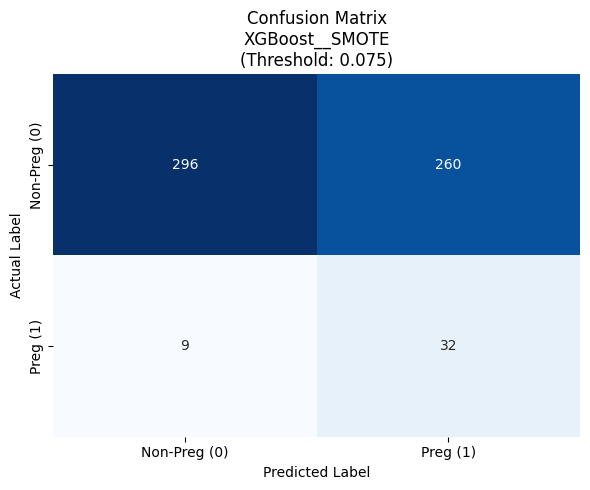

In [120]:
# ==========================================
# Confusion Matrix for Best Model
# ==========================================

top_row = imbalance_results_df.sort_values(
    ["PR-AUC", "ROC-AUC"],
    ascending=False
).iloc[0]

model_name = top_row["Model"]
method_name = top_row["Imbalance_Method"]
threshold = top_row["Optimal_Th_from_TrainCV"]

model_key = f"{model_name}__{method_name}"

y_prob = imbalance_models[model_key]["probs"]
y_pred = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

print(f"Top model: {model_key}")
print(f"Threshold: {threshold:.4f}")
print("Confusion matrix:")
print(cm)

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Precision (PPV): {precision:.3f}")
print(f"NPV: {npv:.3f}")

plot_confusion_matrix(
    y_test,
    y_pred,
    model_key,
    threshold
)

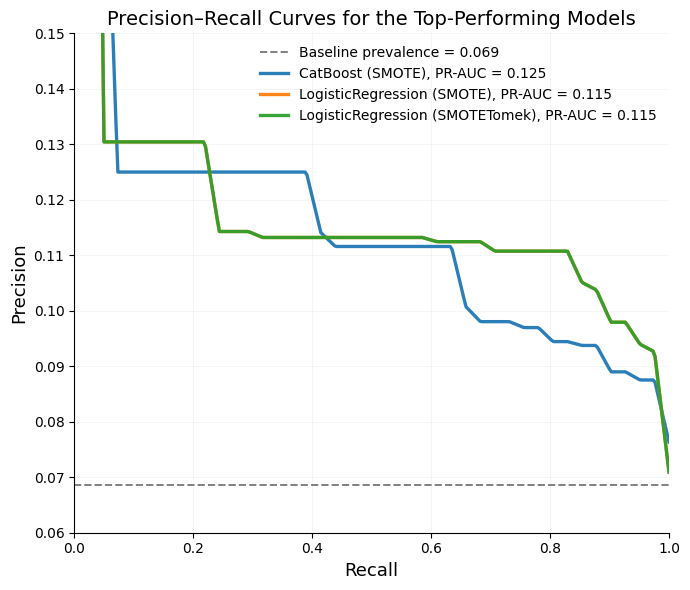

In [10]:
# ==========================================
# Precision–Recall Curves for Top-Performing Models
# Paper-ready version
# ==========================================

from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
import os

top_n = 3

top_models_df = imbalance_results_df.sort_values(
    ["PR-AUC", "ROC-AUC"],
    ascending=False
).head(top_n)

os.makedirs("reports_ours/figures/pr_curves", exist_ok=True)

plt.figure(figsize=(7,6), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

baseline_prevalence = y_test.mean()

# baseline prevalence
plt.axhline(
    baseline_prevalence,
    linestyle="--",
    color="gray",
    linewidth=1.4,
    label=f"Baseline prevalence = {baseline_prevalence:.3f}"
)

recall_grid = np.linspace(0,1,300)

for _, row in top_models_df.iterrows():

    model_name = row["Model"]
    method_name = row["Imbalance_Method"]
    pr_auc = row["PR-AUC"]

    model_key = f"{model_name}__{method_name}"
    y_prob = imbalance_models[model_key]["probs"]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    # sort by recall
    order = np.argsort(recall)
    recall = recall[order]
    precision = precision[order]

    # collapse duplicate recall values
    uniq_recall = np.unique(recall)
    uniq_precision = np.array([
        precision[recall == r].max() for r in uniq_recall
    ])

    # precision envelope
    precision_env = np.maximum.accumulate(uniq_precision[::-1])[::-1]

    # smooth interpolation
    precision_smooth = np.interp(recall_grid, uniq_recall, precision_env)

    label = f"{model_name} ({method_name}), PR-AUC = {pr_auc:.3f}"

    plt.plot(
        recall_grid,
        precision_smooth,
        linewidth=2.4,
        alpha=0.95,
        label=label
    )

plt.xlabel("Recall", fontsize=13)
plt.ylabel("Precision", fontsize=13)
plt.title("Precision–Recall Curves for the Top-Performing Models", fontsize=14)

plt.xlim(0,1)
plt.ylim(0.06,0.15)

# cleaner frame
for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)

plt.grid(alpha=0.15, linewidth=0.6)

plt.legend(
    loc="upper right",
    frameon=False,
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    "reports_ours/figures/pr_curves/top_models_pr_curve_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### 4. Feature Budget Optimization & SHAP XAI
ทำการหาจุดคุ้มทุนแบบพลวัต (Dynamic Cost-Effective Budget) และสร้างกราฟ SHAP ตามจำนวนตัวแปรที่เหมาะสมที่สุด

NameError: name 'budget_df_xgb' is not defined

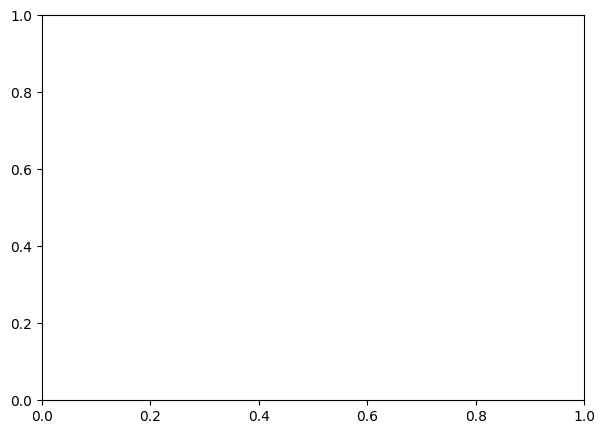

In [11]:
# ==========================================
# Feature Budget Optimization (XGBoost)
# Paper-ready figure
# ==========================================

plt.figure(figsize=(7,5), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

x = budget_df_xgb["Num_Features"]
y = budget_df_xgb["PR-AUC"]

# smoothing (visual only)
y_smooth = y.rolling(window=3, center=True, min_periods=1).mean()

# ------------------------------------------
# Observed CV performance
# ------------------------------------------

plt.plot(
    x,
    y,
    marker="o",
    markersize=3,
    lw=1.2,
    alpha=0.45,
    label="Observed PR-AUC (CV)"
)

# ------------------------------------------
# Smoothed trend
# ------------------------------------------

plt.plot(
    x,
    y_smooth,
    lw=2.6,
    alpha=0.95,
    label="Smoothed trend"
)

# ------------------------------------------
# Optimal feature set
# ------------------------------------------

opt_y = budget_df_xgb.loc[
    budget_df_xgb["Num_Features"] == optimal_k_xgb,
    "PR-AUC"
].iloc[0]

plt.scatter(
    optimal_k_xgb,
    opt_y,
    s=95,
    color="red",
    zorder=6,
    label=f"Optimal feature set (k = {optimal_k_xgb})"
)

# ------------------------------------------
# Best observed PR-AUC reference
# ------------------------------------------

plt.axhline(
    y=max_score_xgb,
    linestyle=":",
    linewidth=1.4,
    color="gray",
    label=f"Best observed PR-AUC = {max_score_xgb:.3f}"
)

# optimal k line

plt.axvline(
    x=optimal_k_xgb,
    linestyle="--",
    linewidth=1.4,
    color="red"
)

# ------------------------------------------
# Labels
# ------------------------------------------

plt.xlabel("Number of Features", fontsize=13)
plt.ylabel("PR-AUC (Cross-validation)", fontsize=13)

plt.title(
    "Feature Budget Optimization for XGBoost",
    fontsize=14
)

plt.xlim(1, x.max())
plt.ylim(y.min()-0.002, y.max()+0.002)

# ------------------------------------------
# Clean journal frame
# ------------------------------------------

for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)

plt.grid(alpha=0.18)

plt.legend(
    loc="lower right",
    frameon=False,
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    "reports_ours/figures/feature_budget_xgb_smote_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [8]:
# ==========================================
# Block 7: Final Model Evaluation + SHAP Analysis
# Final model = XGBoost + Baseline after feature budget
# ==========================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss
)

os.makedirs("reports_test/figures/shap_final_xgb", exist_ok=True)
os.makedirs("reports_test/tables", exist_ok=True)
os.makedirs("models_test/final_model", exist_ok=True)

# -----------------------------
# Required objects
# -----------------------------
required_objects = [
    "selected_features_xgb",
    "final_xgb_model",
    "X_test",
    "y_test",
    "test_info"
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Please run the previous blocks first.")

# -----------------------------
# Final feature set
# -----------------------------
final_features = selected_features_xgb.copy()

missing_features = [f for f in final_features if f not in X_test.columns]
if missing_features:
    raise ValueError(f"These final features are missing from X_test: {missing_features}")

X_test_final = X_test[final_features].copy()

print("Final features used:")
for i, f in enumerate(final_features, start=1):
    print(f"  {i}. {f}")

# -----------------------------
# Final model probabilities on TEST
# -----------------------------
final_probs   = final_xgb_model.predict_proba(X_test_final)[:, 1]

final_pr_auc  = average_precision_score(y_test, final_probs)
final_roc_auc = roc_auc_score(y_test, final_probs)
final_brier   = brier_score_loss(y_test, final_probs)

print("\nFinal model performance on test set:")
print(f"PR-AUC:  {final_pr_auc:.4f}")
print(f"ROC-AUC: {final_roc_auc:.4f}")
print(f"Brier:   {final_brier:.4f}")

# -----------------------------
# Save final performance summary
# -----------------------------
final_model_summary = pd.DataFrame([{
    "Model": "XGBoost + Baseline (Final Feature-Budget Model)",
    "Num_Features": len(final_features),
    "PR-AUC":  final_pr_auc,
    "ROC-AUC": final_roc_auc,
    "Brier":   final_brier
}])

final_model_summary.to_excel(
    "reports_test/tables/Final_Model_Performance_XGBoost_Baseline.xlsx",
    index=False
)

# -----------------------------
# Save final selected features
# -----------------------------
final_features_df = pd.DataFrame({
    "Rank":    range(1, len(final_features) + 1),
    "Feature": final_features
})

final_features_df.to_excel(
    "reports_test/tables/Final_Selected_Features_XGBoost_Baseline.xlsx",
    index=False
)

# -----------------------------
# Save final test-set predictions
# -----------------------------
final_test_pred_df = test_info.copy()
final_test_pred_df["y_true"] = y_test.values
final_test_pred_df["y_prob"] = final_probs

final_test_pred_df.to_excel(
    "reports_test/tables/Final_Test_Predictions_XGBoost_Baseline.xlsx",
    index=False
)

# -----------------------------
# Feature name map for display
# -----------------------------
feature_name_map = {
    'Age_Female': 'Female Age',
    'Body_Mass_Index': 'BMI',
    'Total_infertile_duration': 'Infertility Duration',
    'Infertility_Type': 'Primary Infertility',
    'Pregnancy_History': 'Previous Pregnancy',
    'Number_Of_Alive_Children': 'Number of Children',
    'Number_Of_Miscarriages': 'Number of Miscarriages',
    'Menstrual': 'Regular Menstrual Cycle',
    'Menstrual_Interval_Days': 'Cycle Interval (days)',
    'Menstrual_Duration_Days': 'Menstrual Duration (days)',
    'Dysmenorrhea': 'Dysmenorrhea',
    'FSH_Baseline': 'Baseline FSH',
    'LH_Baseline': 'Baseline LH',
    'E2_Baseline': 'Baseline Estradiol',
    'PRL_Baseline': 'Baseline Prolactin',
    'Uterine_Factors': 'Uterine Factor',
    'Tubal_Factors': 'Tubal Factor',
    'Ovarian_Factors': 'Ovarian Factor',
    'Ovulatory_Factors': 'Ovulatory Factor',
    'Cervical_Factors': 'Cervical Factor',
    'Endometriosis_Factors': 'Endometriosis',
    'Multisystem_Factors': 'Multiple Infertility Factors',
    'Gynecological_Surgical_History': 'Gynecologic Surgery History',
    'Alcohol': 'Male Alcohol Consumption',
    'Smoke': 'Male Smoking',
    'First_Volume': 'Initial Semen Volume',
    'First_Count': 'Initial Sperm Count',
    'First_Motile': 'Initial Motility',
    'First_Progressive_Motile': 'Initial Progressive Motility',
    'First_Normal_Morpho': 'Initial Normal Morphology',
    'Pre_Volume': 'Prewash Volume',
    'Pre_Count': 'Prewash Sperm Count',
    'Pre_Motile': 'Prewash Motility',
    'Pre_Progressive_Motile': 'Prewash Progressive Motility',
    'Pre_TPMSC': 'Prewash TPMSC',
    'Post_Count': 'Postwash Sperm Count',
    'Post_Motile': 'Postwash Motility',
    'Post_Progressive_Motile': 'Postwash Progressive Motility',
    'Post_TPMSC': 'Postwash TPMSC',
    'Cycle_Type': 'Cycle Type',
    'Cycle_Day': 'IUI Cycle Day',
    'Cycle_Number': 'IUI Cycle Number',
    'Ovary_Stimulation_Round': 'Stimulation Round',
    'OI_Clomiphene': 'Clomiphene',
    'OI_Letrozole': 'Letrozole',
    'OI_Gonadotropins': 'Gonadotropins',
    'hCG_Used': 'hCG Trigger Used',
    'hCG_Type': 'hCG Type',
    'Mature_Follicle_Count': 'Mature Follicle Count',
    'Endometrium_Thickness': 'Endometrial Thickness',
    'Endo_Type_Triple': 'Triple Line Endometrium',
    'Endo_Type_Intermediate': 'Intermediate Endometrium',
    'Endo_Type_Mixed': 'Mixed Endometrium',
    # Feature engineering
    'Ratio_TPMSC': 'TPMSC Wash Ratio',
    'Delta_Progressive_Motile': 'Δ Progressive Motility',
    'Delta_Motile': 'Δ Total Motility',
    'Follicle_Endo_Product': 'Follicle × Endometrium',
    'Cumulative_Treatment': 'Cumulative Treatment',
    'Age_FSH_Interaction': 'Age × FSH',
    'BMI_InfertilityType_Interaction': 'BMI × Infertility Type',
    'Total_Female_Pathology': 'Total Female Pathology',
    'First_TotalMotile': 'Initial Total Motile Sperm'
}

display_names = [feature_name_map.get(f, f) for f in final_features]

X_test_final_named         = X_test_final.copy()
X_test_final_named.columns = display_names

# -----------------------------
# SHAP explainer
# -----------------------------
explainer   = shap.TreeExplainer(final_xgb_model)
shap_values = explainer.shap_values(X_test_final)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

if not isinstance(shap_values, np.ndarray):
    raise ValueError("Unexpected SHAP output format.")

if shap_values.shape[1] != X_test_final.shape[1]:
    raise ValueError(
        f"SHAP shape mismatch: shap_values has {shap_values.shape[1]} features, "
        f"but X_test_final has {X_test_final.shape[1]} features."
    )

# -----------------------------
# SHAP feature importance table
# -----------------------------
feat_imp_final_xgb = pd.DataFrame({
    "Feature":         final_features,
    "Feature_Display": display_names,
    "Importance":      np.abs(shap_values).mean(axis=0)
}).sort_values("Importance", ascending=False).reset_index(drop=True)

feat_imp_final_xgb.to_excel(
    "reports_test/tables/SHAP_Feature_Importance_Final_XGBoost_Baseline.xlsx",
    index=False
)

print("\nTop SHAP features:")
print(feat_imp_final_xgb.to_string())

# -----------------------------
# SHAP bar plot
# -----------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_final_named,
    plot_type="bar",
    max_display=len(final_features),
    show=False
)
plt.title("SHAP Feature Importance - Final XGBoost + Baseline Model")
plt.tight_layout()
plt.savefig(
    "reports_test/figures/shap_final_xgb/SHAP_Bar_Final_XGBoost_Baseline.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

# -----------------------------
# SHAP beeswarm plot
# -----------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_final_named,
    max_display=len(final_features),
    show=False
)
plt.title("SHAP Summary Plot - Final XGBoost + Baseline Model")
plt.tight_layout()
plt.savefig(
    "reports_test/figures/shap_final_xgb/SHAP_Beeswarm_Final_XGBoost_Baseline.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

print("\n✅ Block 7 complete")
print("Saved files:")
print("- models_test/final_model/XGBoost_Baseline_final_feature_budget_model.joblib")
print("- reports_test/tables/Final_Model_Performance_XGBoost_Baseline.xlsx")
print("- reports_test/tables/Final_Selected_Features_XGBoost_Baseline.xlsx")
print("- reports_test/tables/Final_Test_Predictions_XGBoost_Baseline.xlsx")
print("- reports_test/tables/SHAP_Feature_Importance_Final_XGBoost_Baseline.xlsx")
print("- reports_test/figures/shap_final_xgb/SHAP_Bar_Final_XGBoost_Baseline.png")
print("- reports_test/figures/shap_final_xgb/SHAP_Beeswarm_Final_XGBoost_Baseline.png")

ValueError: selected_features_xgb not found. Please run the previous blocks first.

<Figure size 640x480 with 0 Axes>

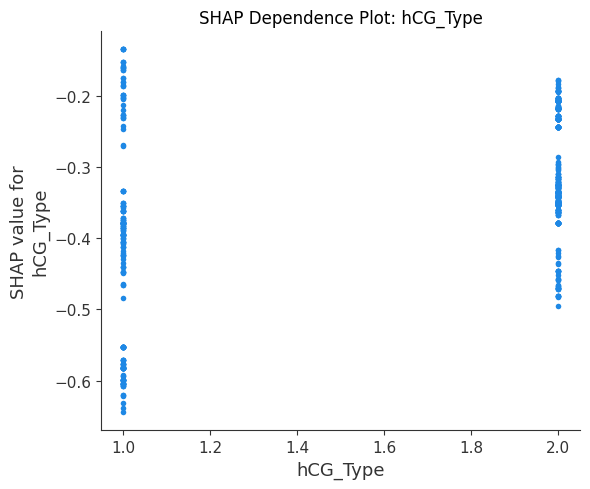

<Figure size 640x480 with 0 Axes>

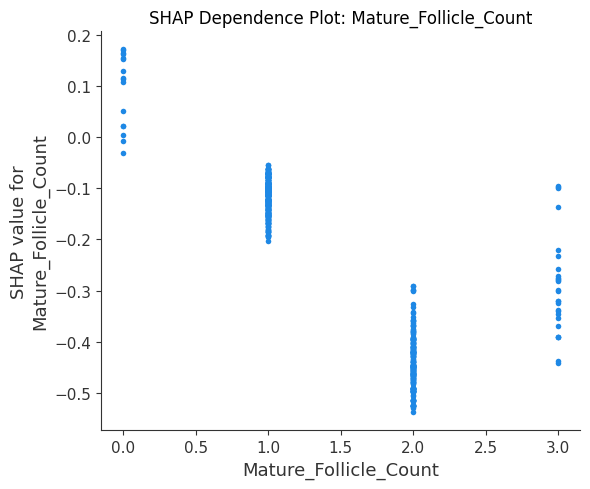

<Figure size 640x480 with 0 Axes>

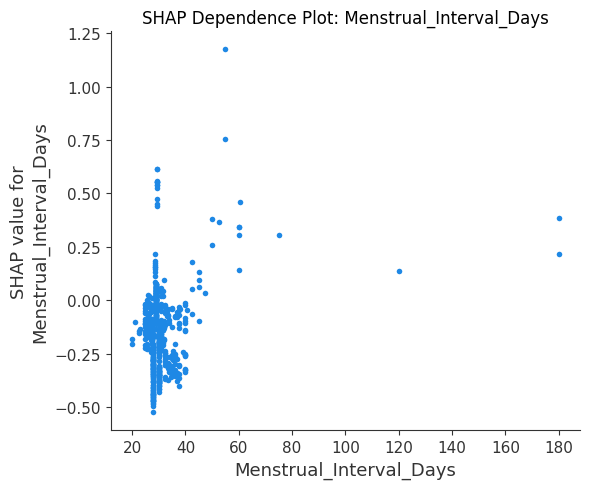

<Figure size 640x480 with 0 Axes>

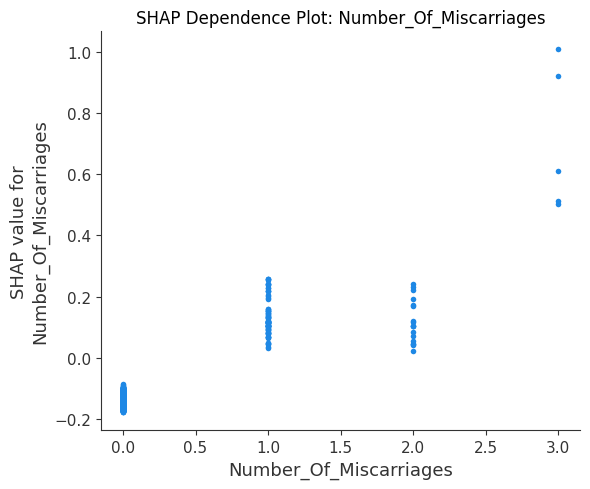

<Figure size 640x480 with 0 Axes>

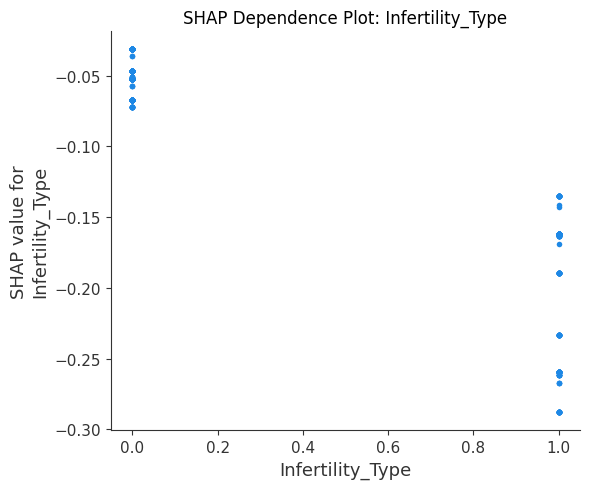

In [116]:
# ==========================================
# Block 7B: SHAP Dependence Plots
# ==========================================

import os
import shap
import matplotlib.pyplot as plt

os.makedirs("reports_ours/figures/shap_dependence", exist_ok=True)

# features to inspect for directionality
features_to_check = [
    "hCG_Type",
    "Mature_Follicle_Count",
    "Menstrual_Interval_Days",
    "Number_Of_Miscarriages",
    "Infertility_Type"
]

for feat in features_to_check:

    if feat not in final_features:
        print(f"{feat} not in final feature set, skipping")
        continue

    plt.figure()

    shap.dependence_plot(
        feat,
        shap_values,
        X_test_final,
        interaction_index=None,
        show=False
    )

    plt.title(f"SHAP Dependence Plot: {feat}")
    plt.tight_layout()

    plt.savefig(
        f"reports_ours/figures/shap_dependence/SHAP_Dependence_{feat}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [119]:
# ==========================================
# Final XGBoost model outputs
# Using model from Block 6B
# ==========================================

if 'selected_features_xgb' not in globals():
    raise ValueError("selected_features_xgb not found. Run Block 6B first.")

if 'final_xgb_model' not in globals():
    raise ValueError("final_xgb_model not found. Run Block 6B first.")

final_features = selected_features_xgb.copy()

X_train_final = X_train[final_features].copy()
X_test_final = X_test[final_features].copy()

final_model = final_xgb_model

if hasattr(final_model, "feature_names_in_"):
    assert list(final_model.feature_names_in_) == list(final_features), \
        "Feature mismatch between final model and final feature set"

final_probs = final_model.predict_proba(X_test_final)[:, 1]

print("Final features:")
for i, f in enumerate(final_features, start=1):
    print(f"{i}. {f}")

print("\nfinal_probs ready.")

Final features:
1. Uterine_Factors
2. Endo_Type_Triple
3. Cycle_Day
4. hCG_Type
5. Dysmenorrhea
6. Infertility_Type
7. Number_Of_Miscarriages
8. Mature_Follicle_Count
9. Age_Female
10. Ovary_Stimulation_Round
11. Cycle_Number
12. Menstrual_Interval_Days
13. Pre_Motile

final_probs ready.


In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(
    y_test,
    final_probs,
    n_bins=6,
    strategy="quantile"
)


plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")

plt.xlabel("Predicted probability")
plt.ylabel("Observed probability")
plt.title("Calibration Plot - Final XGBoost Model")
plt.legend()
plt.tight_layout()
plt.show()

print("Brier score:", brier_score_loss(y_test, final_probs))

Final features:
1. Uterine_Factors
2. Endo_Type_Triple
3. Cycle_Day
4. hCG_Type
5. Dysmenorrhea
6. Infertility_Type
7. Number_Of_Miscarriages
8. Mature_Follicle_Count
9. Age_Female
10. Ovary_Stimulation_Round
11. Cycle_Number
12. Menstrual_Interval_Days
13. Pre_Motile

final_probs ready.


Dependence features to plot: ['Uterine_Factors', 'Cycle_Number', 'hCG_Type', 'Endo_Type_Triple', 'Pre_Motile', 'Dysmenorrhea', 'Mature_Follicle_Count', 'Age_Female', 'Menstrual_Interval_Days', 'Cycle_Day', 'Ovary_Stimulation_Round', 'Number_Of_Miscarriages', 'Infertility_Type']


<Figure size 800x600 with 0 Axes>

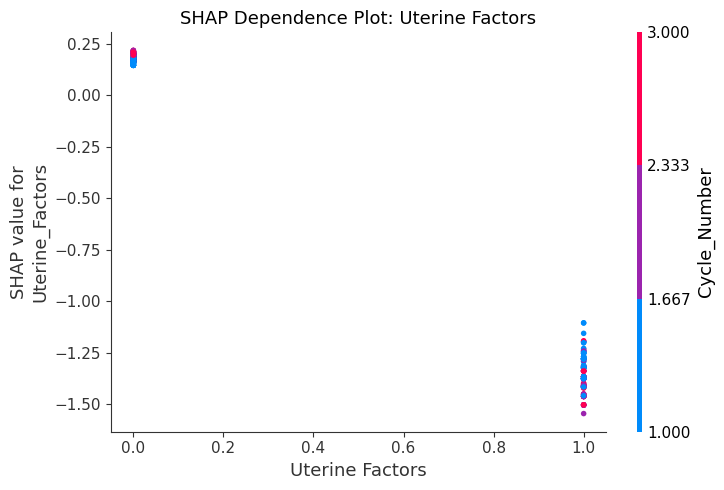

<Figure size 800x600 with 0 Axes>

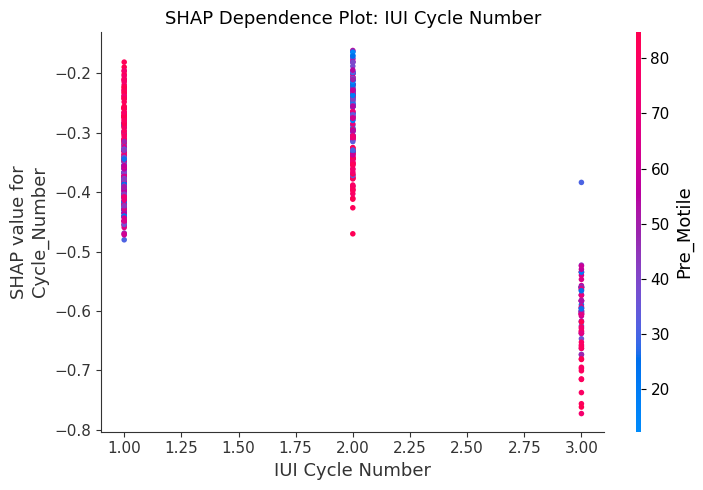

<Figure size 800x600 with 0 Axes>

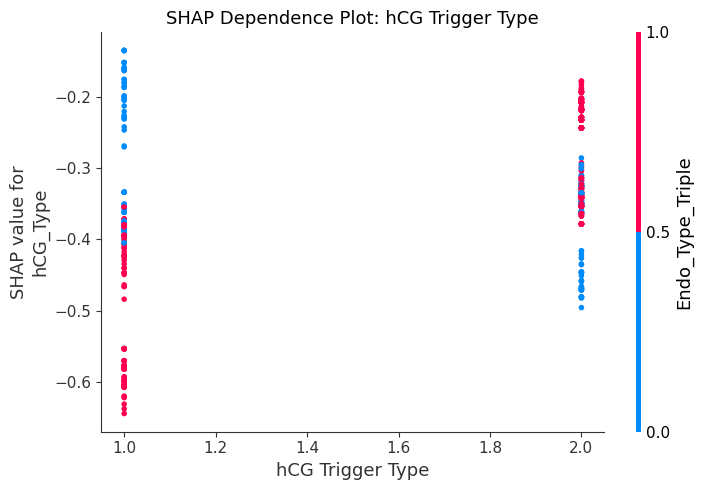

<Figure size 800x600 with 0 Axes>

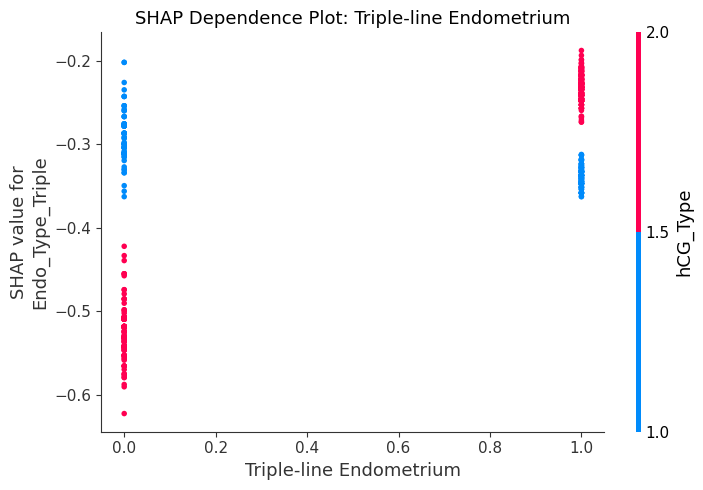

<Figure size 800x600 with 0 Axes>

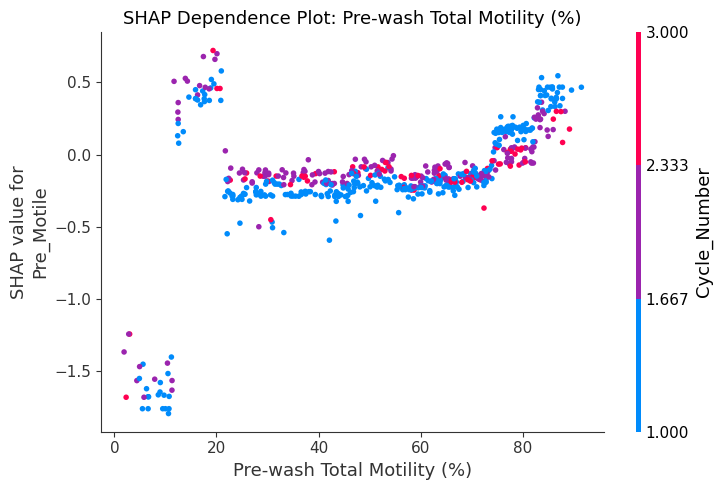

<Figure size 800x600 with 0 Axes>

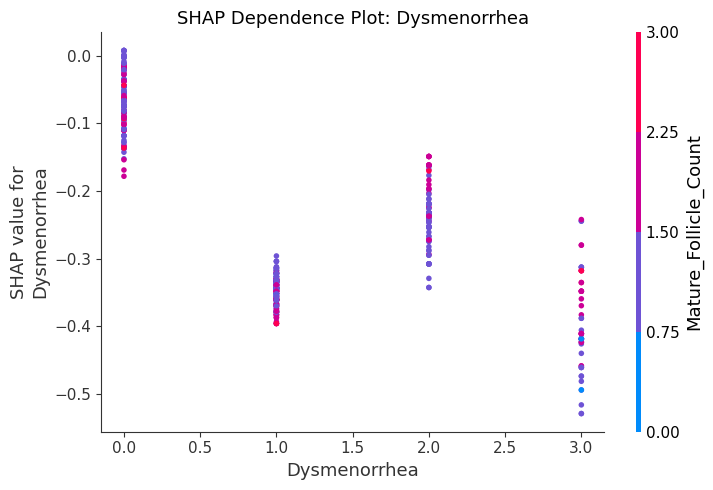

<Figure size 800x600 with 0 Axes>

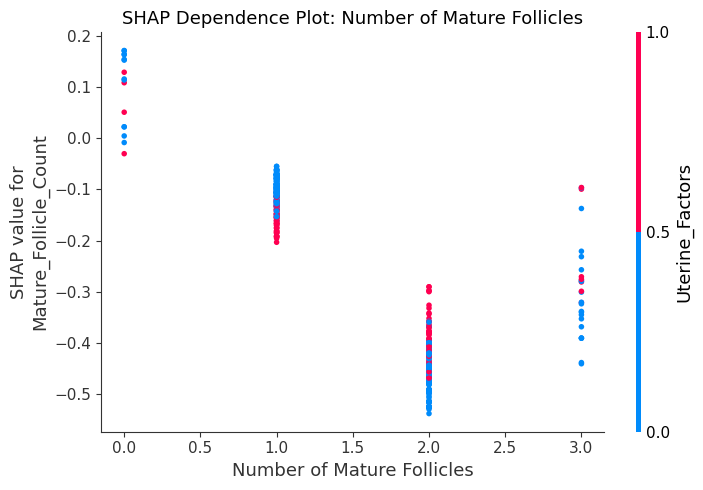

<Figure size 800x600 with 0 Axes>

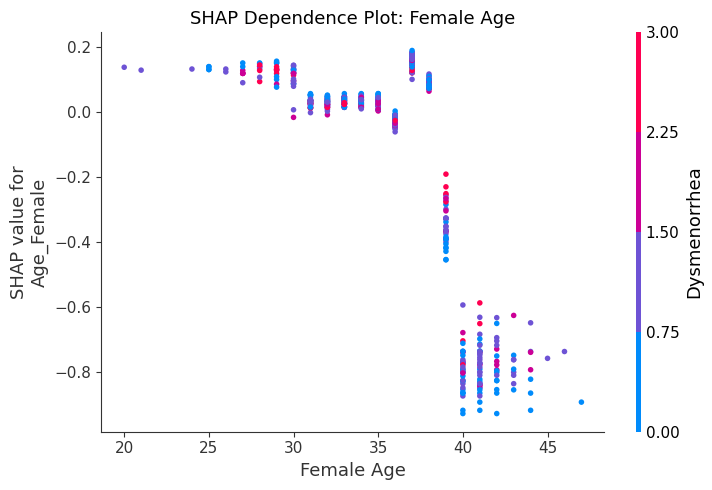

<Figure size 800x600 with 0 Axes>

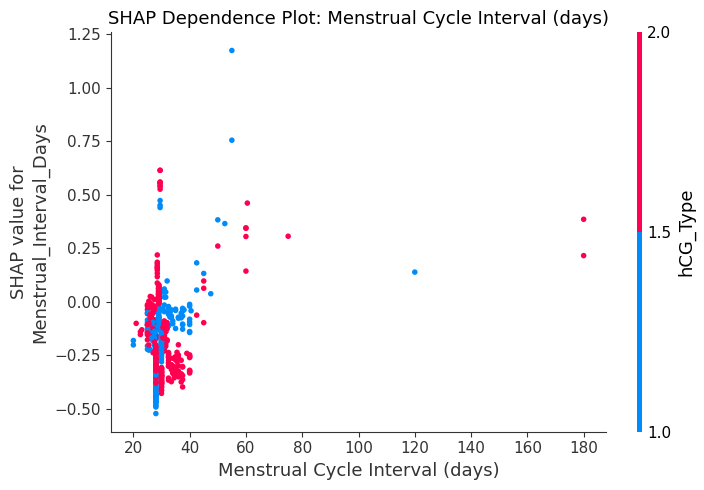

<Figure size 800x600 with 0 Axes>

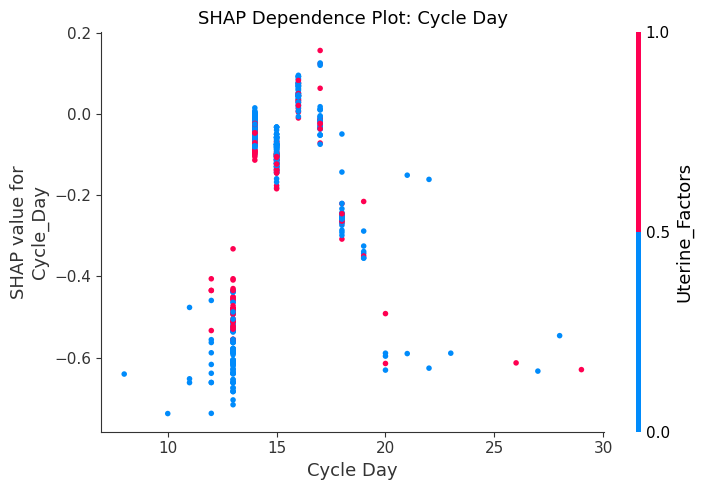

<Figure size 800x600 with 0 Axes>

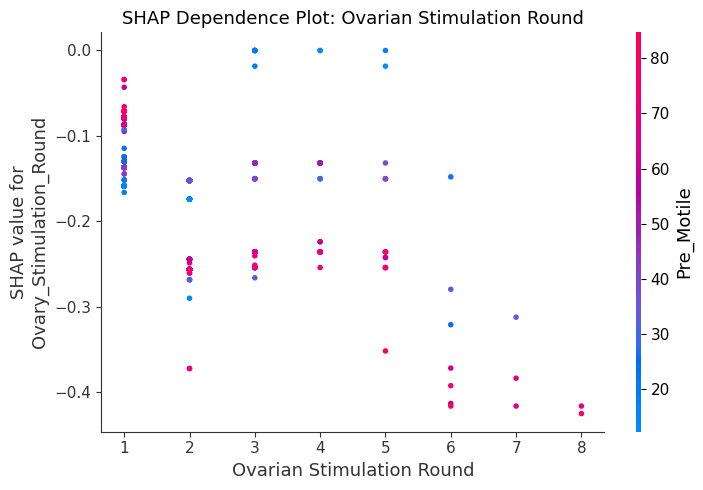

<Figure size 800x600 with 0 Axes>

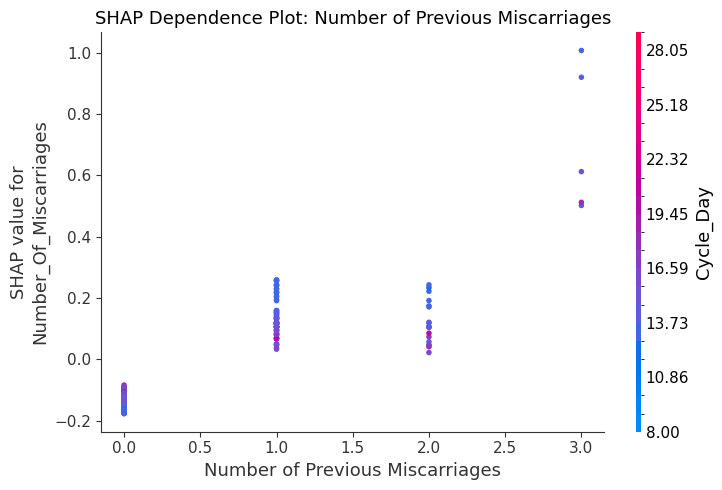

<Figure size 800x600 with 0 Axes>

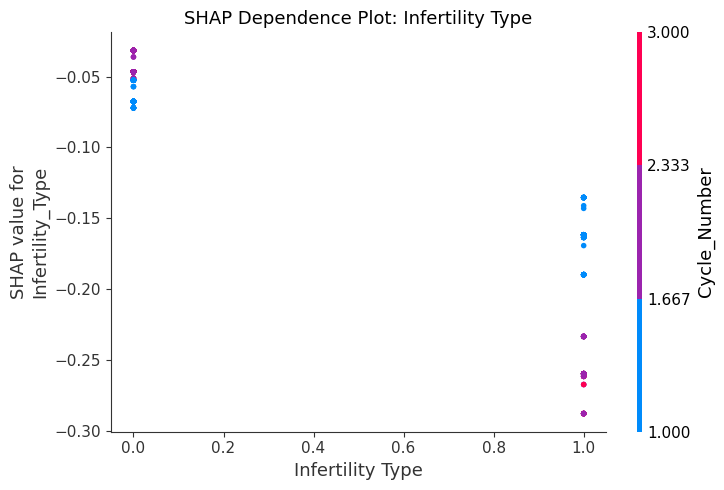

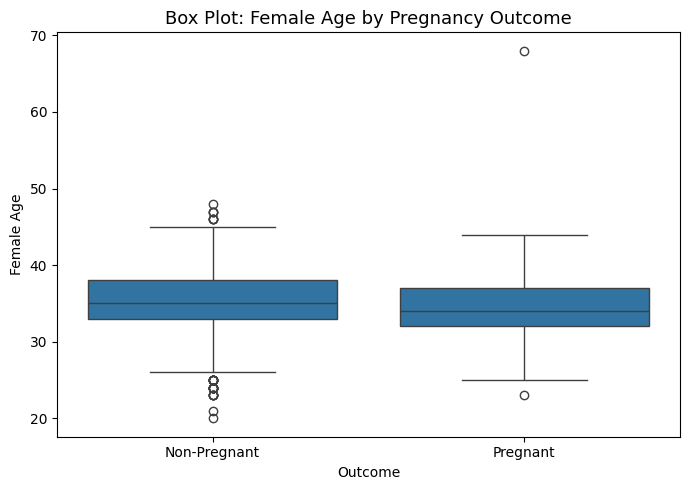

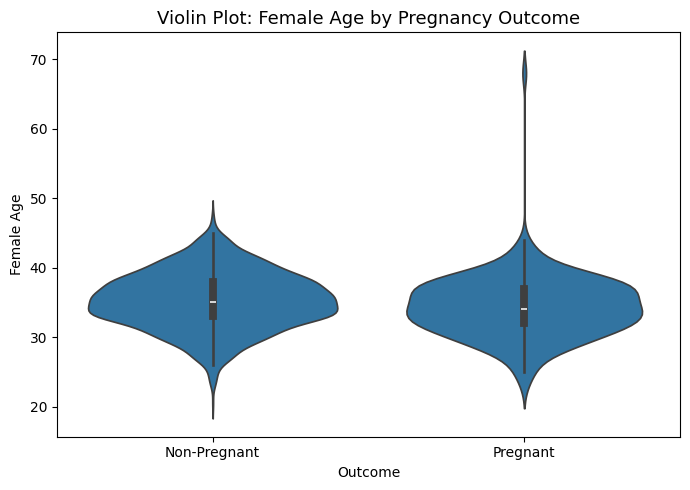

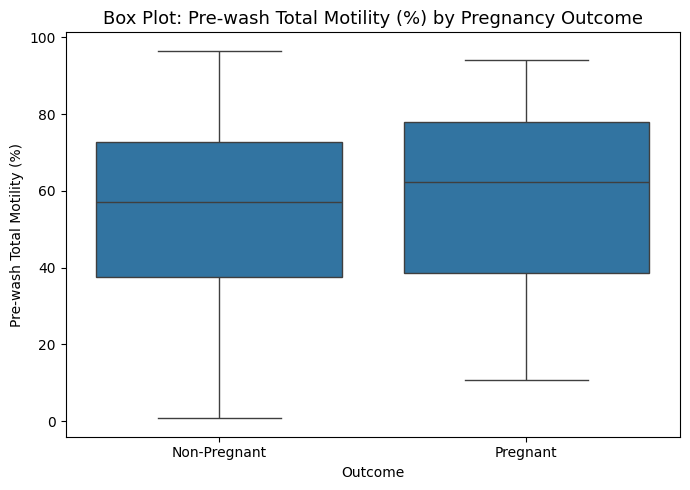

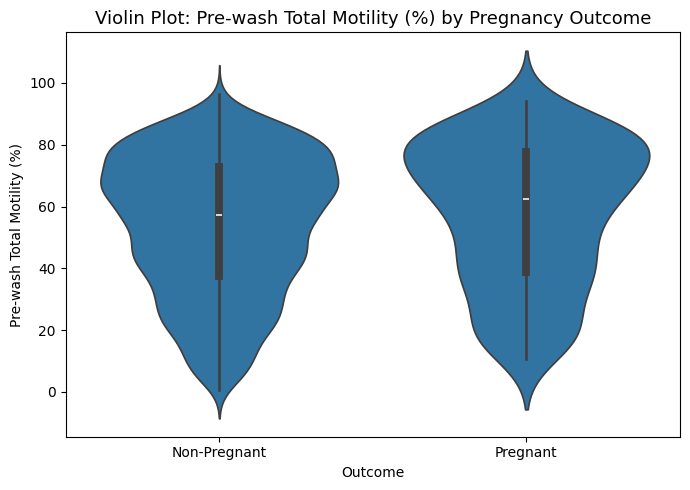

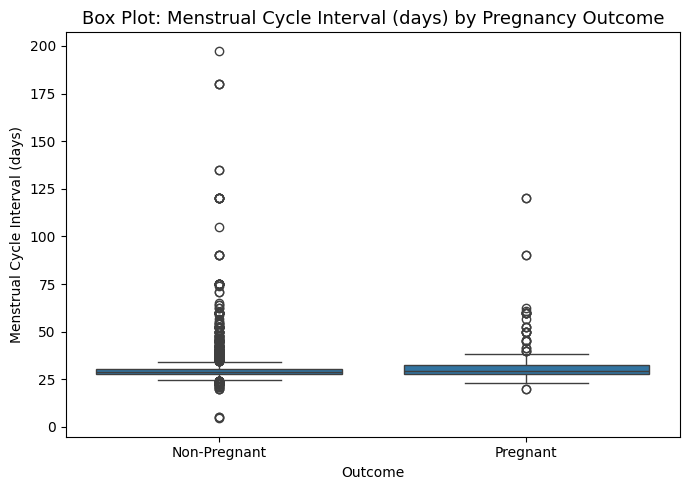

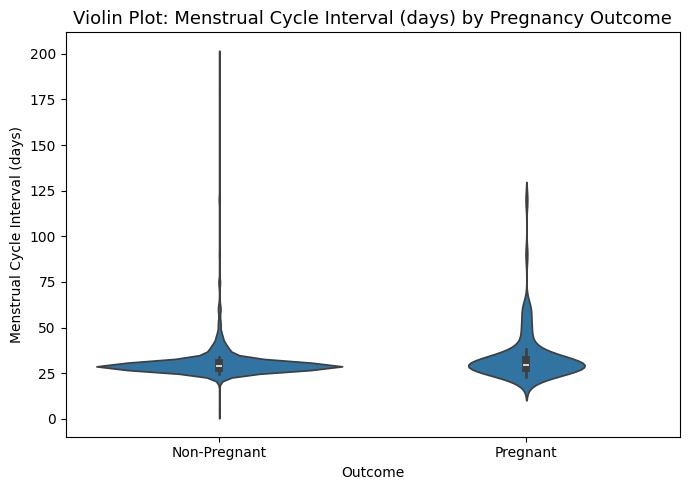

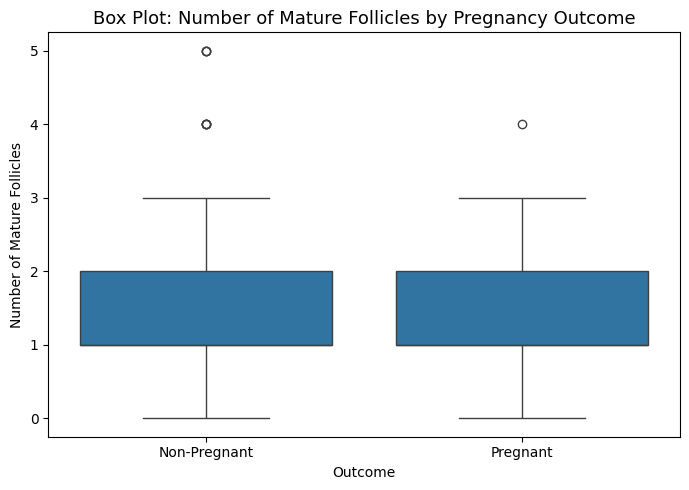

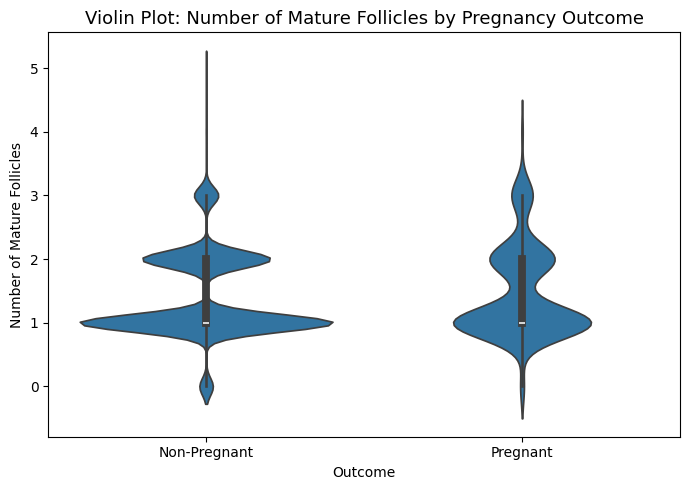

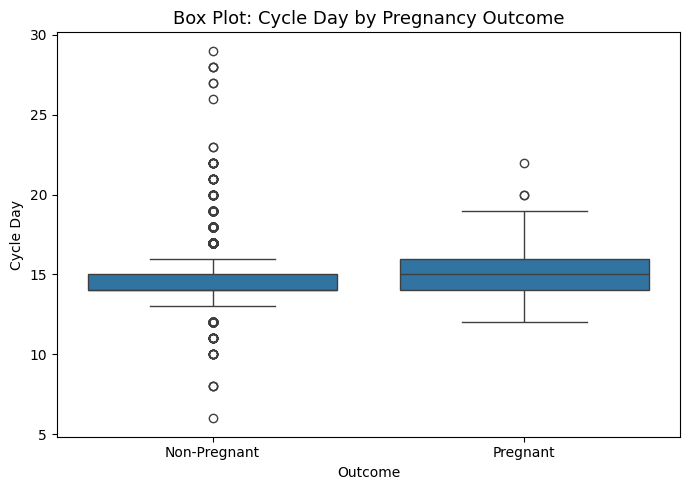

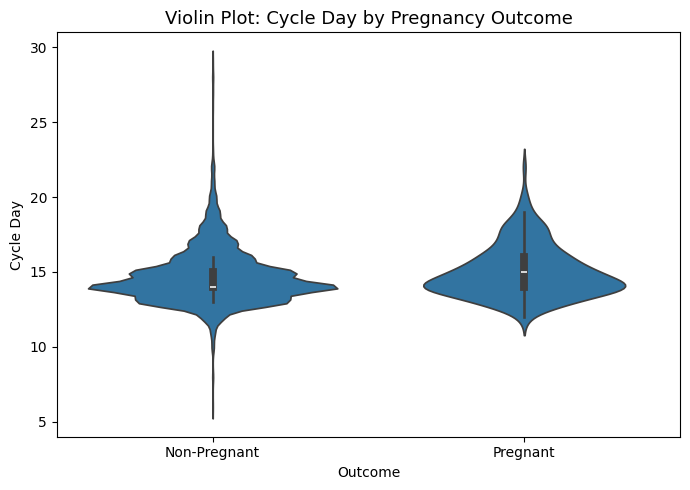

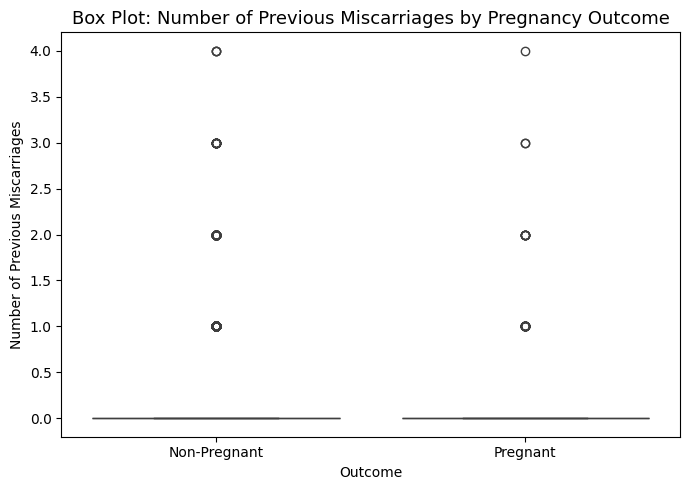

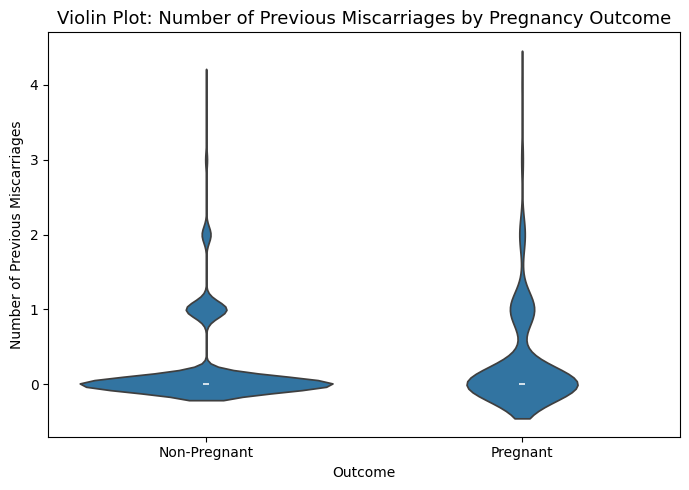

<Figure size 800x600 with 0 Axes>

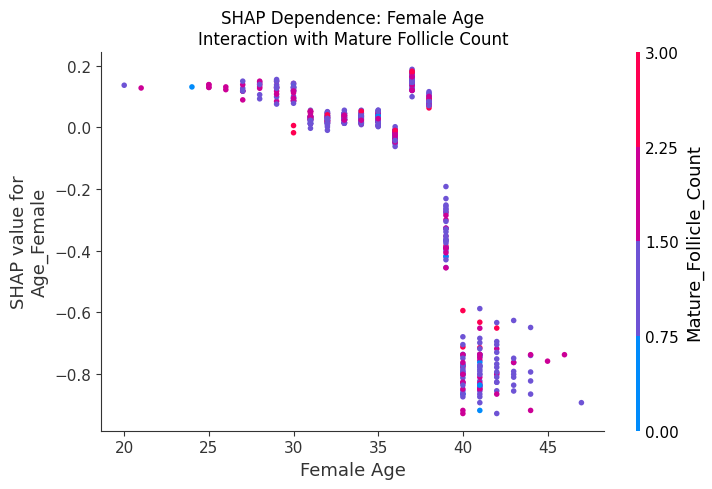

In [99]:
# =========================
# 4.3 SHAP Dependence Plots
# =========================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

os.makedirs('reports_ours/figures/shap_dependence', exist_ok=True)
os.makedirs('reports_ours/figures/clinical_plots', exist_ok=True)

# ใช้ object จาก final model block
if 'feat_imp_final_xgb' not in globals():
    raise ValueError("feat_imp_final_xgb not found. Please run final SHAP block first.")

if 'shap_values' not in globals():
    raise ValueError("shap_values not found. Please run final SHAP block first.")

if 'X_test_final' not in globals():
    raise ValueError("X_test_final not found. Please run final model block first.")

if 'final_features' not in globals():
    raise ValueError("final_features not found. Please run final model block first.")

# เลือก dependence plots จาก feature ที่สำคัญจริงตาม SHAP ล่าสุด
candidate_dependence_features = [
    'Uterine_Factors',
    'Cycle_Number',
    'hCG_Type',
    'Endo_Type_Triple',
    'Pre_Motile',
    'Dysmenorrhea',
    'Mature_Follicle_Count',
    'Age_Female',
    'Menstrual_Interval_Days',
    'Cycle_Day',
    'Ovary_Stimulation_Round',
    'Number_Of_Miscarriages',
    'Infertility_Type'
]

top_feature_set = set(feat_imp_final_xgb['Feature'].head(15).tolist())
dependence_features = [
    f for f in candidate_dependence_features
    if f in X_test_final.columns and f in top_feature_set
]

print("Dependence features to plot:", dependence_features)

for feat in dependence_features:
    display_name = feature_name_map.get(feat, feat) if 'feature_name_map' in globals() else feat

    plt.figure(figsize=(8, 6))
    shap.dependence_plot(
        feat,
        shap_values,
        X_test_final,
        interaction_index='auto',
        show=False
    )
    plt.title(f'SHAP Dependence Plot: {display_name}', fontsize=13)
    plt.xlabel(display_name)
    plt.tight_layout()
    plt.savefig(
        f'reports_ours/figures/shap_dependence/SHAP_Dependence_{feat}.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
    plt.close()


# ==========================================
# 4.4 Clinical Box / Violin Plots by Outcome
# ==========================================

plot_df = df.copy()
plot_df = plot_df.loc[:, ~plot_df.columns.str.startswith('Unnamed')]

plot_df['Result'] = pd.to_numeric(plot_df['Result'], errors='coerce')
plot_df = plot_df.dropna(subset=['Result'])

plot_df['Pregnancy_Label'] = plot_df['Result'].map({
    0: 'Non-Pregnant',
    1: 'Pregnant'
})

# เน้นตัวที่เข้ากับ final SHAP และเล่า biology ได้
clinical_plot_features = [
    'Age_Female',
    'Pre_Motile',
    'Menstrual_Interval_Days',
    'Mature_Follicle_Count',
    'Cycle_Day',
    'Number_Of_Miscarriages'
]

for feat in clinical_plot_features:
    if feat in plot_df.columns:
        display_name = feature_name_map.get(feat, feat) if 'feature_name_map' in globals() else feat

        tmp = plot_df[['Pregnancy_Label', feat]].copy()
        tmp[feat] = pd.to_numeric(tmp[feat], errors='coerce')
        tmp = tmp.dropna(subset=[feat, 'Pregnancy_Label'])

        if tmp.empty:
            print(f"⚠️ ไม่มีข้อมูลใช้ plot สำหรับ {feat}")
            continue

        # Boxplot
        plt.figure(figsize=(7, 5))
        sns.boxplot(
            data=tmp,
            x='Pregnancy_Label',
            y=feat
        )
        plt.title(f'Box Plot: {display_name} by Pregnancy Outcome', fontsize=13)
        plt.xlabel('Outcome')
        plt.ylabel(display_name)
        plt.tight_layout()
        plt.savefig(
            f'reports_ours/figures/clinical_plots/BoxPlot_{feat}_by_Result.png',
            dpi=300,
            bbox_inches='tight'
        )
        plt.show()
        plt.close()

        # Violin plot
        plt.figure(figsize=(7, 5))
        sns.violinplot(
            data=tmp,
            x='Pregnancy_Label',
            y=feat,
            inner='box'
        )
        plt.title(f'Violin Plot: {display_name} by Pregnancy Outcome', fontsize=13)
        plt.xlabel('Outcome')
        plt.ylabel(display_name)
        plt.tight_layout()
        plt.savefig(
            f'reports_ours/figures/clinical_plots/ViolinPlot_{feat}_by_Result.png',
            dpi=300,
            bbox_inches='tight'
        )
        plt.show()
        plt.close()
    else:
        print(f"⚠️ ไม่พบคอลัมน์ {feat} ใน plot_df เลยข้ามไป")


# ==========================================
# 4.5 Selected SHAP Interaction Plot
# ==========================================
# ปรับให้เข้ากับ final model ล่าสุด:
# Female Age × Mature Follicle Count

if {'Age_Female', 'Mature_Follicle_Count'}.issubset(X_test_final.columns):
    plt.figure(figsize=(8, 6))

    shap.dependence_plot(
        'Age_Female',
        shap_values,
        X_test_final,
        interaction_index='Mature_Follicle_Count',
        show=False
    )

    plt.title('SHAP Dependence: Female Age\nInteraction with Mature Follicle Count')
    plt.xlabel('Female Age')
    plt.tight_layout()

    plt.savefig(
        'reports_ours/figures/shap_dependence/SHAP_Dependence_FemaleAge_interaction_MatureFollicleCount.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()
    plt.close()
else:
    print("⚠️ ไม่พบ Age_Female หรือ Mature_Follicle_Count ใน X_test_final")

### 5. Clinical Analysis 1: Risk Stratification

Risk thresholds: q50=0.0764, q80=0.1513


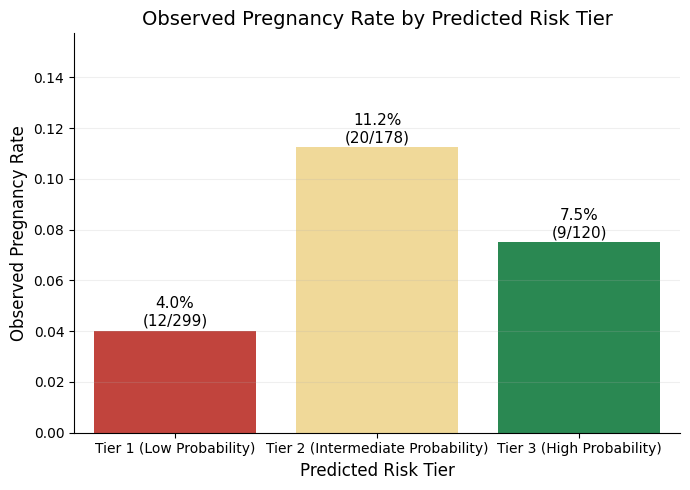


Risk Tier Summary:
                           Risk_Tier  Total_Cycles  Actual_Pregnancies  \
0           Tier 1 (Low Probability)           299                  12   
1  Tier 2 (Intermediate Probability)           178                  20   
2          Tier 3 (High Probability)           120                   9   

   Avg_Predicted_Prob  Min_Predicted_Prob  Max_Predicted_Prob  \
0            0.037073            0.001406            0.076372   
1            0.112953            0.076427            0.150183   
2            0.220188            0.151526            0.502662   

   Unique_Patients  Observed_Pregnancy_Rate  Predicted_minus_Observed  
0              206                 0.040134                 -0.003061  
1              137                 0.112360                  0.000593  
2              100                 0.075000                  0.145188  


In [134]:
# =========================
# Block 8: Risk Tier Analysis (Clinical Split)
# 50 / 30 / 20
# =========================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('reports_ours/tables', exist_ok=True)
os.makedirs('reports_ours/figures/clinical', exist_ok=True)

risk_df = test_info.copy()
risk_df['Predicted_Prob'] = final_probs
risk_df['Actual_Result'] = y_test.values

risk_df = risk_df.dropna(subset=['Predicted_Prob','Actual_Result']).copy()

# -----------------------------
# Define clinical thresholds
# -----------------------------

q50 = risk_df['Predicted_Prob'].quantile(0.50)
q80 = risk_df['Predicted_Prob'].quantile(0.80)

tier_labels = [
    'Tier 1 (Low Probability)',
    'Tier 2 (Intermediate Probability)',
    'Tier 3 (High Probability)'
]

risk_df['Risk_Tier'] = pd.cut(
    risk_df['Predicted_Prob'],
    bins=[-np.inf, q50, q80, np.inf],
    labels=tier_labels,
    include_lowest=True
)

print(f"Risk thresholds: q50={q50:.4f}, q80={q80:.4f}")

# -----------------------------
# Summary table
# -----------------------------

tier_summary = (
    risk_df
    .groupby('Risk_Tier', observed=False)
    .agg(
        Total_Cycles=('Actual_Result','count'),
        Actual_Pregnancies=('Actual_Result','sum'),
        Avg_Predicted_Prob=('Predicted_Prob','mean'),
        Min_Predicted_Prob=('Predicted_Prob','min'),
        Max_Predicted_Prob=('Predicted_Prob','max')
    )
    .reset_index()
)

if 'HN' in risk_df.columns:

    patient_counts = (
        risk_df
        .groupby('Risk_Tier')['HN']
        .nunique()
        .reset_index(name='Unique_Patients')
    )

    tier_summary = tier_summary.merge(patient_counts,on='Risk_Tier',how='left')

tier_summary['Observed_Pregnancy_Rate'] = (
    tier_summary['Actual_Pregnancies'] /
    tier_summary['Total_Cycles']
)

tier_summary['Predicted_minus_Observed'] = (
    tier_summary['Avg_Predicted_Prob'] -
    tier_summary['Observed_Pregnancy_Rate']
)

tier_summary['Risk_Tier'] = pd.Categorical(
    tier_summary['Risk_Tier'],
    categories=tier_labels,
    ordered=True
)

tier_summary = tier_summary.sort_values('Risk_Tier')

tier_summary.to_excel(
    'reports_ours/tables/Risk_Tier_Summary_FinalModel_50_30_20.xlsx',
    index=False
)

# -----------------------------
# Plot (journal style)
# -----------------------------

tier_colors = ['#d73027','#fee08b','#1a9850']

plt.figure(figsize=(7,5), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

sns.barplot(
    x='Risk_Tier',
    y='Observed_Pregnancy_Rate',
    data=tier_summary,
    palette=tier_colors
)

plt.title(
    'Observed Pregnancy Rate by Predicted Risk Tier',
    fontsize=14
)

plt.ylabel('Observed Pregnancy Rate', fontsize=12)
plt.xlabel('Predicted Risk Tier', fontsize=12)

ymax = tier_summary['Observed_Pregnancy_Rate'].max()
plt.ylim(0, ymax*1.4)

for i,row in tier_summary.iterrows():

    label = (
        f"{row['Observed_Pregnancy_Rate']:.1%}\n"
        f"({int(row['Actual_Pregnancies'])}/{int(row['Total_Cycles'])})"
    )

    plt.text(
        i,
        row['Observed_Pregnancy_Rate']+0.002,
        label,
        ha='center',
        fontsize=11
    )

for spine in ['top','right']:
    ax.spines[spine].set_visible(False)

plt.grid(axis='y',alpha=0.2)

plt.tight_layout()

plt.savefig(
    'reports_ours/figures/clinical/Risk_Tier_Analysis_FinalModel_50_30_20.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\nRisk Tier Summary:")
print(tier_summary)

Selected cutoffs from search: c1=0.0277, c2=0.1018
Selected quantiles: q1=0.20, q2=0.60


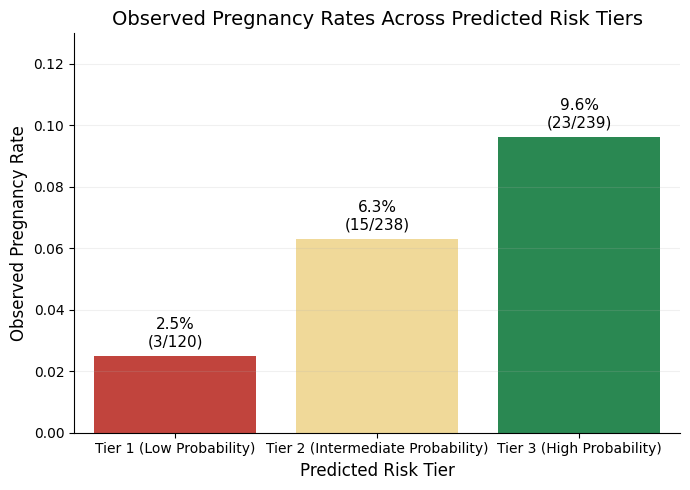


Risk Tier Summary:
                           Risk_Tier  Total_Cycles  Actual_Pregnancies  \
0           Tier 1 (Low Probability)           120                   3   
1  Tier 2 (Intermediate Probability)           238                  15   
2          Tier 3 (High Probability)           239                  23   

   Avg_Predicted_Prob  Min_Predicted_Prob  Max_Predicted_Prob  \
0            0.017249            0.001406            0.027720   
1            0.059667            0.027858            0.101174   
2            0.172980            0.102300            0.502662   

   Unique_Patients  Observed_Pregnancy_Rate  Predicted_minus_Observed  
0               91                 0.025000                 -0.007751  
1              186                 0.063025                 -0.003358  
2              169                 0.096234                  0.076746  


In [135]:
# =========================
# Block 8: Risk Tier Analysis (Monotonic / Pretty version)
# Search cut points that force Low < Mid < High
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('reports_ours/tables', exist_ok=True)
os.makedirs('reports_ours/figures/clinical', exist_ok=True)

risk_df = test_info.copy()
risk_df['Predicted_Prob'] = final_probs
risk_df['Actual_Result'] = y_test.values
risk_df = risk_df.dropna(subset=['Predicted_Prob', 'Actual_Result']).copy()

tier_labels = [
    'Tier 1 (Low Probability)',
    'Tier 2 (Intermediate Probability)',
    'Tier 3 (High Probability)'
]

# --------------------------------
# search candidate cutoffs
# keep each tier at least 15% of data
# --------------------------------
q_grid = np.arange(0.20, 0.81, 0.05)

best_result = None
best_score = -np.inf

for q1 in q_grid:
    for q2 in q_grid:
        if q2 <= q1:
            continue

        c1 = risk_df['Predicted_Prob'].quantile(q1)
        c2 = risk_df['Predicted_Prob'].quantile(q2)

        tmp = risk_df.copy()
        tmp['Risk_Tier'] = pd.cut(
            tmp['Predicted_Prob'],
            bins=[-np.inf, c1, c2, np.inf],
            labels=tier_labels,
            include_lowest=True
        )

        counts = tmp['Risk_Tier'].value_counts().reindex(tier_labels)
        if counts.isna().any():
            continue

        # require each group to have enough size
        if (counts < int(len(tmp) * 0.15)).any():
            continue

        rates = (
            tmp.groupby('Risk_Tier', observed=False)['Actual_Result']
            .mean()
            .reindex(tier_labels)
        )

        # force monotonic increase
        if not (rates.iloc[0] < rates.iloc[1] < rates.iloc[2]):
            continue

        # score: prefer wider separation and reasonable group balance
        separation = (rates.iloc[2] - rates.iloc[0]) + 0.5 * (rates.iloc[1] - rates.iloc[0])
        balance_penalty = counts.std() / counts.mean()
        score = separation - 0.02 * balance_penalty

        if score > best_score:
            best_score = score
            best_result = {
                'q1': q1,
                'q2': q2,
                'c1': c1,
                'c2': c2,
                'rates': rates,
                'counts': counts
            }

if best_result is None:
    raise ValueError(
        "No monotonic 3-tier split found with current constraints. "
        "Try relaxing the minimum tier size or widening q_grid."
    )

# --------------------------------
# apply best cutoffs
# --------------------------------
c1 = best_result['c1']
c2 = best_result['c2']

risk_df['Risk_Tier'] = pd.cut(
    risk_df['Predicted_Prob'],
    bins=[-np.inf, c1, c2, np.inf],
    labels=tier_labels,
    include_lowest=True
)

print(f"Selected cutoffs from search: c1={c1:.4f}, c2={c2:.4f}")
print(f"Selected quantiles: q1={best_result['q1']:.2f}, q2={best_result['q2']:.2f}")

# --------------------------------
# summary table
# --------------------------------
tier_summary = (
    risk_df
    .groupby('Risk_Tier', observed=False)
    .agg(
        Total_Cycles=('Actual_Result', 'count'),
        Actual_Pregnancies=('Actual_Result', 'sum'),
        Avg_Predicted_Prob=('Predicted_Prob', 'mean'),
        Min_Predicted_Prob=('Predicted_Prob', 'min'),
        Max_Predicted_Prob=('Predicted_Prob', 'max')
    )
    .reset_index()
)

if 'HN' in risk_df.columns:
    patient_counts = (
        risk_df
        .groupby('Risk_Tier', observed=False)['HN']
        .nunique()
        .reset_index(name='Unique_Patients')
    )
    tier_summary = tier_summary.merge(patient_counts, on='Risk_Tier', how='left')

tier_summary['Observed_Pregnancy_Rate'] = (
    tier_summary['Actual_Pregnancies'] / tier_summary['Total_Cycles']
)

tier_summary['Predicted_minus_Observed'] = (
    tier_summary['Avg_Predicted_Prob'] - tier_summary['Observed_Pregnancy_Rate']
)

tier_summary['Risk_Tier'] = pd.Categorical(
    tier_summary['Risk_Tier'],
    categories=tier_labels,
    ordered=True
)
tier_summary = tier_summary.sort_values('Risk_Tier').reset_index(drop=True)

tier_summary.to_excel(
    'reports_ours/tables/Risk_Tier_Summary_FinalModel_Monotonic.xlsx',
    index=False
)

# --------------------------------
# plot
# --------------------------------
tier_colors = ['#d73027', '#fee08b', '#1a9850']

plt.figure(figsize=(7,5), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

sns.barplot(
    x='Risk_Tier',
    y='Observed_Pregnancy_Rate',
    data=tier_summary,
    palette=tier_colors
)

plt.title('Observed Pregnancy Rates Across Predicted Risk Tiers', fontsize=14)
plt.ylabel('Observed Pregnancy Rate', fontsize=12)
plt.xlabel('Predicted Risk Tier', fontsize=12)

ymax = tier_summary['Observed_Pregnancy_Rate'].max()
plt.ylim(0, ymax * 1.35)

for i, row in tier_summary.iterrows():
    label = (
        f"{row['Observed_Pregnancy_Rate']:.1%}\n"
        f"({int(row['Actual_Pregnancies'])}/{int(row['Total_Cycles'])})"
    )
    plt.text(
        i,
        row['Observed_Pregnancy_Rate'] + 0.002,
        label,
        ha='center',
        va='bottom',
        fontsize=11
    )

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.grid(axis='y', alpha=0.18)
plt.tight_layout()

plt.savefig(
    'reports_ours/figures/clinical/Risk_Tier_Analysis_FinalModel_Monotonic.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("\nRisk Tier Summary:")
print(tier_summary)

### 6. Clinical Analysis 2: Cumulative Cycle Impact

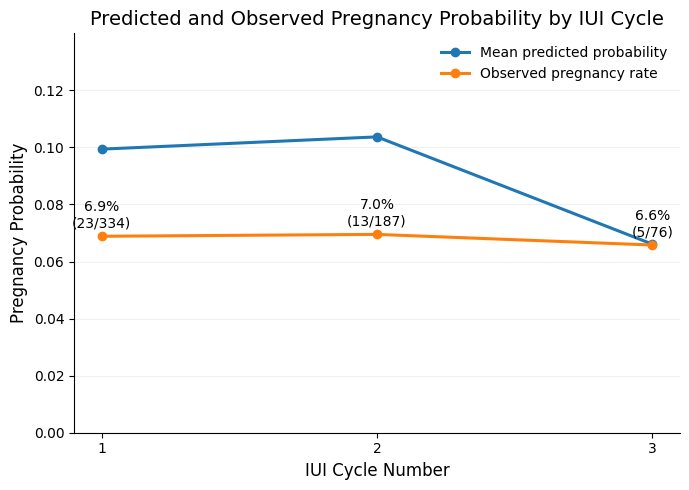


Cycle Summary:
   Cycle_Number  Total_Cycles  Actual_Pregnancies  Avg_Predicted_Prob  \
0             1           334                  23            0.099399   
1             2           187                  13            0.103698   
2             3            76                   5            0.066083   

   Observed_Pregnancy_Rate  
0                 0.068862  
1                 0.069519  
2                 0.065789  


In [137]:
# =========================
# Cycle Number Analysis
# Paper-ready version
# =========================

import os
import matplotlib.pyplot as plt

os.makedirs('reports_ours/tables', exist_ok=True)
os.makedirs('reports_ours/figures/clinical', exist_ok=True)

if 'Cycle_Number' in test_info.columns:

    cycle_summary = (
        test_info
        .groupby('Cycle_Number')
        .agg(
            Total_Cycles=('Actual_Result', 'count'),
            Actual_Pregnancies=('Actual_Result', 'sum'),
            Avg_Predicted_Prob=('Predicted_Prob', 'mean')
        )
        .reset_index()
    )

    cycle_summary['Observed_Pregnancy_Rate'] = (
        cycle_summary['Actual_Pregnancies'] /
        cycle_summary['Total_Cycles']
    )

    cycle_summary = cycle_summary[cycle_summary['Cycle_Number'].isin([1, 2, 3])].copy()
    cycle_summary = cycle_summary.sort_values('Cycle_Number')

    cycle_summary.to_excel(
        'reports_ours/tables/Cycle_Number_Summary.xlsx',
        index=False
    )

    plt.figure(figsize=(7, 5), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')

    plt.plot(
        cycle_summary['Cycle_Number'],
        cycle_summary['Avg_Predicted_Prob'],
        marker='o',
        linewidth=2.2,
        label='Mean predicted probability'
    )

    plt.plot(
        cycle_summary['Cycle_Number'],
        cycle_summary['Observed_Pregnancy_Rate'],
        marker='o',
        linewidth=2.2,
        label='Observed pregnancy rate'
    )

    for _, row in cycle_summary.iterrows():
        plt.text(
            row['Cycle_Number'],
            row['Observed_Pregnancy_Rate'] + 0.002,
            f"{row['Observed_Pregnancy_Rate']:.1%}\n({int(row['Actual_Pregnancies'])}/{int(row['Total_Cycles'])})",
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.xticks([1, 2, 3])
    plt.xlabel('IUI Cycle Number', fontsize=12)
    plt.ylabel('Pregnancy Probability', fontsize=12)
    plt.title('Predicted and Observed Pregnancy Probability by IUI Cycle', fontsize=14)

    ymax = max(
        cycle_summary['Avg_Predicted_Prob'].max(),
        cycle_summary['Observed_Pregnancy_Rate'].max()
    )
    plt.ylim(0, ymax * 1.35)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.grid(axis='y', alpha=0.18)
    plt.legend(frameon=False)
    plt.tight_layout()

    plt.savefig(
        'reports_ours/figures/clinical/Cycle_Number_Analysis_Final.png',
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.show()

    print("\nCycle Summary:")
    print(cycle_summary)

else:
    print("ไม่มีตัวแปร Cycle_Number ให้วิเคราะห์")


CUMULATIVE PREGNANCY SUMMARY
   Patients  Avg_Predicted_Cumulative_Prob  Observed_Pregnancy_Rate
0       353                       0.153475                 0.116147


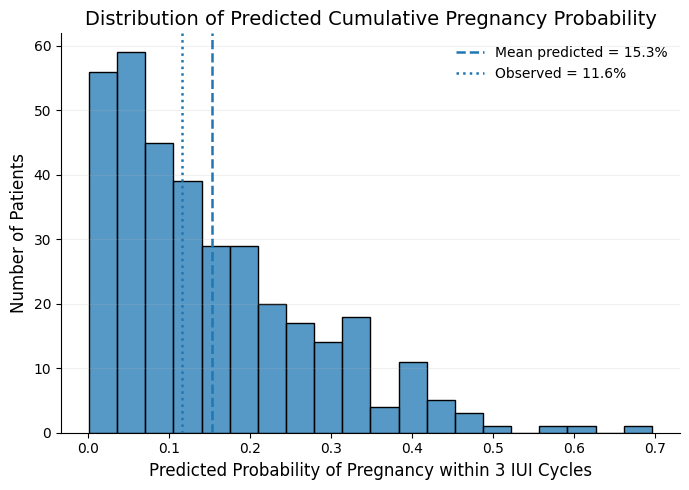

In [138]:
# ===============================
# 7. CUMULATIVE PREGNANCY ANALYSIS
# Paper-ready version
# ===============================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('reports_ours/figures/clinical', exist_ok=True)
os.makedirs('reports_ours/tables', exist_ok=True)

if 'Cycle_Number' in test_info.columns:

    cum_df = test_info[test_info['Cycle_Number'] <= 3].copy()
    cum_df = cum_df.sort_values(['HN', 'Cycle_Number'])

    cumulative_results = []

    for hn, g in cum_df.groupby('HN'):
        g = g.sort_values('Cycle_Number')

        p = g['Predicted_Prob'].values
        cum_prob = 1 - np.prod(1 - p)

        cumulative_results.append({
            'HN': hn,
            'Num_Cycles': len(g),
            'Cumulative_Predicted_Prob': cum_prob,
            'Actual_Pregnancy': g['Actual_Result'].max()
        })

    cumulative_df = pd.DataFrame(cumulative_results)

    cumulative_df.to_excel(
        'reports_ours/tables/Cumulative_Patient_Level.xlsx',
        index=False
    )

    cumulative_summary_df = pd.DataFrame([{
        "Patients": len(cumulative_df),
        "Avg_Predicted_Cumulative_Prob": cumulative_df['Cumulative_Predicted_Prob'].mean(),
        "Observed_Pregnancy_Rate": cumulative_df['Actual_Pregnancy'].mean()
    }])

    cumulative_summary_df.to_excel(
        'reports_ours/tables/Cumulative_Summary.xlsx',
        index=False
    )

    print("\nCUMULATIVE PREGNANCY SUMMARY")
    print(cumulative_summary_df)

    plt.figure(figsize=(7, 5), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')

    sns.histplot(
        cumulative_df['Cumulative_Predicted_Prob'],
        bins=20
    )

    mean_pred = cumulative_df['Cumulative_Predicted_Prob'].mean()
    obs_rate = cumulative_df['Actual_Pregnancy'].mean()

    plt.axvline(
        mean_pred,
        linestyle='--',
        linewidth=1.8,
        label=f'Mean predicted = {mean_pred:.1%}'
    )

    plt.axvline(
        obs_rate,
        linestyle=':',
        linewidth=1.8,
        label=f'Observed = {obs_rate:.1%}'
    )

    plt.xlabel('Predicted Probability of Pregnancy within 3 IUI Cycles', fontsize=12)
    plt.ylabel('Number of Patients', fontsize=12)
    plt.title('Distribution of Predicted Cumulative Pregnancy Probability', fontsize=14)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.grid(axis='y', alpha=0.18)
    plt.legend(frameon=False)
    plt.tight_layout()

    plt.savefig(
        'reports_ours/figures/clinical/Cumulative_Pregnancy_Distribution.png',
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.show()

else:
    print("Cycle_Number not available")


Cumulative Success Summary:
   Cycle  Observed_Cumulative_Pregnancy_Rate  \
0      1                            0.065156   
1      2                            0.101983   
2      3                            0.116147   

   Model_Estimated_Cumulative_Probability  
0                                0.099893  
1                                0.143854  
2                                0.153475  


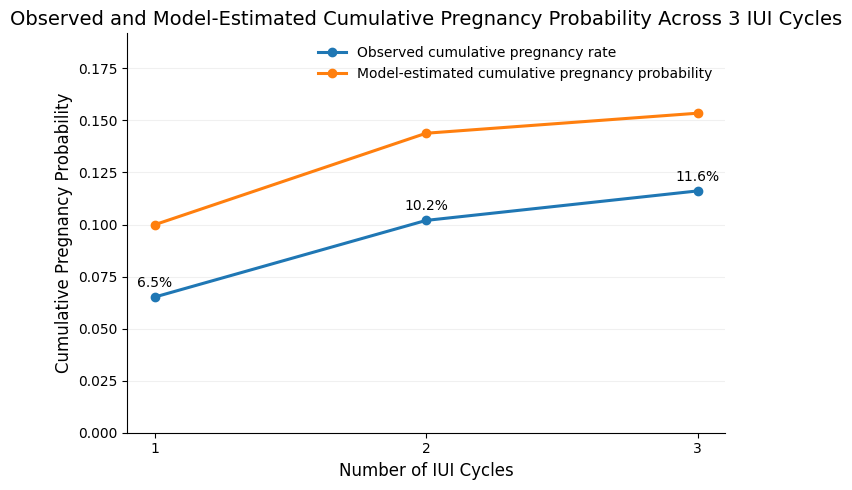

In [141]:
# =========================================
# 8. COHORT-LEVEL CUMULATIVE SUCCESS (1–3)
# Paper-ready version
# =========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs('reports_ours/tables', exist_ok=True)
os.makedirs('reports_ours/figures/clinical', exist_ok=True)

if 'Cycle_Number' in test_info.columns and 'HN' in test_info.columns:

    cum_plot_df = test_info.copy()

    cum_plot_df['Actual_Result'] = y_test.values
    cum_plot_df['Predicted_Prob'] = final_probs

    # ใช้เฉพาะ cycle 1–3
    cum_plot_df = cum_plot_df[cum_plot_df['Cycle_Number'] <= 3].copy()
    cum_plot_df = cum_plot_df.sort_values(['HN', 'Cycle_Number'])

    patient_ids = cum_plot_df['HN'].dropna().unique()

    # -----------------------------
    # Observed cumulative pregnancy
    # -----------------------------
    actual_rows = []

    for k in [1, 2, 3]:

        sub = cum_plot_df[cum_plot_df['Cycle_Number'] <= k].copy()

        preg_by_k = (
            sub.groupby('HN')['Actual_Result']
            .max()
            .reindex(patient_ids, fill_value=0)
        )

        actual_rows.append({
            'Cycle': k,
            'Observed_Cumulative_Pregnancy_Rate': preg_by_k.mean()
        })

    actual_cum_df = pd.DataFrame(actual_rows)

    # -----------------------------
    # Model-estimated cumulative probability
    # -----------------------------
    pred_rows = []

    for k in [1, 2, 3]:

        sub = cum_plot_df[cum_plot_df['Cycle_Number'] <= k].copy()

        patient_pred = []

        for hn in patient_ids:

            g = sub[sub['HN'] == hn].sort_values('Cycle_Number')

            if len(g) == 0:
                continue

            p = g['Predicted_Prob'].values
            cum_prob = 1 - np.prod(1 - p)

            patient_pred.append(cum_prob)

        pred_rows.append({
            'Cycle': k,
            'Model_Estimated_Cumulative_Probability': np.mean(patient_pred)
        })

    pred_cum_df = pd.DataFrame(pred_rows)

    # -----------------------------
    # Merge summary
    # -----------------------------
    cumulative_summary_df = actual_cum_df.merge(pred_cum_df, on='Cycle')

    cumulative_summary_df.to_excel(
        'reports_ours/tables/Cumulative_Success_By_Cycle.xlsx',
        index=False
    )

    print("\nCumulative Success Summary:")
    print(cumulative_summary_df)

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(7,5), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')

    plt.plot(
        cumulative_summary_df['Cycle'],
        cumulative_summary_df['Observed_Cumulative_Pregnancy_Rate'],
        marker='o',
        linewidth=2.2,
        label='Observed cumulative pregnancy rate'
    )

    plt.plot(
        cumulative_summary_df['Cycle'],
        cumulative_summary_df['Model_Estimated_Cumulative_Probability'],
        marker='o',
        linewidth=2.2,
        label='Model-estimated cumulative pregnancy probability'
    )

    # annotation
    for _, row in cumulative_summary_df.iterrows():

        plt.text(
            row['Cycle'],
            row['Observed_Cumulative_Pregnancy_Rate'] + 0.005,
            f"{row['Observed_Cumulative_Pregnancy_Rate']:.1%}",
            ha='center',
            fontsize=10
        )

    plt.xticks([1,2,3])
    plt.xlabel('Number of IUI Cycles', fontsize=12)
    plt.ylabel('Cumulative Pregnancy Probability', fontsize=12)

    plt.title(
        'Observed and Model-Estimated Cumulative Pregnancy Probability Across 3 IUI Cycles',
        fontsize=14
    )

    ymax = max(
        cumulative_summary_df['Observed_Cumulative_Pregnancy_Rate'].max(),
        cumulative_summary_df['Model_Estimated_Cumulative_Probability'].max()
    )

    plt.ylim(0, ymax * 1.25)

    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)

    plt.grid(axis='y', alpha=0.18)
    plt.legend(frameon=False)

    plt.tight_layout()

    plt.savefig(
        'reports_ours/figures/clinical/Cumulative_Success_By_Cycle.png',
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.show()

else:
    print("ต้องมีทั้ง HN และ Cycle_Number เพื่อคำนวณ cumulative success")


Cumulative Pregnancy by Risk Tier:
                           Risk_Tier  Cycle  Patients_in_Tier  \
0           Tier 1 (Low Probability)      1                91   
1           Tier 1 (Low Probability)      2                91   
2           Tier 1 (Low Probability)      3                91   
3  Tier 2 (Intermediate Probability)      1               186   
4  Tier 2 (Intermediate Probability)      2               186   
5  Tier 2 (Intermediate Probability)      3               186   
6          Tier 3 (High Probability)      1               169   
7          Tier 3 (High Probability)      2               169   
8          Tier 3 (High Probability)      3               169   

   Observed_Cumulative_Pregnancy_Rate  Pregnancies_by_Cycle_k  
0                            0.021978                       2  
1                            0.032967                       3  
2                            0.032967                       3  
3                            0.048387                    

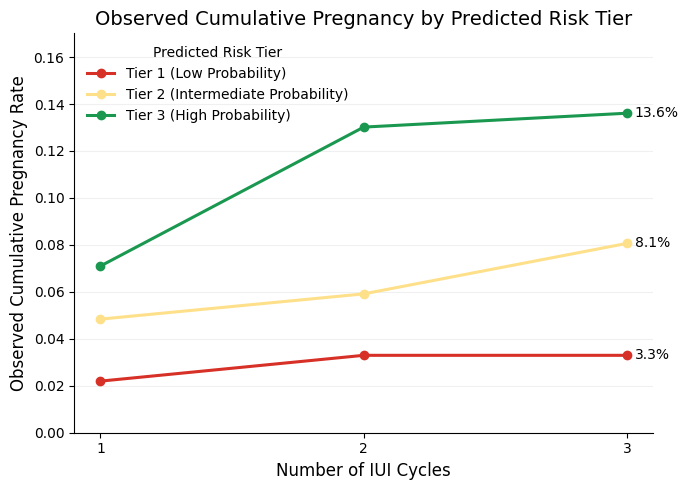

In [142]:
# ==========================================
# 9. CUMULATIVE PREGNANCY BY RISK TIER (1–3)
# Paper-ready version
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs('reports_ours/tables', exist_ok=True)
os.makedirs('reports_ours/figures/clinical', exist_ok=True)

if 'HN' in test_info.columns and 'Cycle_Number' in test_info.columns:

    tier_cum_df = test_info.copy()
    tier_cum_df['Actual_Result'] = y_test.values
    tier_cum_df['Predicted_Prob'] = final_probs

    # ใช้เฉพาะ cycle 1–3
    tier_cum_df = tier_cum_df[tier_cum_df['Cycle_Number'] <= 3].copy()
    tier_cum_df = tier_cum_df.sort_values(['HN', 'Cycle_Number'])

    # --------------------------------
    # Use monotonic risk-tier cutoffs if available
    # --------------------------------
    tier_order = [
        'Tier 1 (Low Probability)',
        'Tier 2 (Intermediate Probability)',
        'Tier 3 (High Probability)'
    ]

    if 'c1' not in globals() or 'c2' not in globals():
        raise ValueError("Risk-tier cutoffs c1 and c2 not found. Run the monotonic risk-tier block first.")

    tier_cum_df['Risk_Tier'] = pd.cut(
        tier_cum_df['Predicted_Prob'],
        bins=[-np.inf, c1, c2, np.inf],
        labels=tier_order,
        include_lowest=True
    )

    cumulative_rows = []

    for tier in tier_order:
        sub_tier = tier_cum_df[tier_cum_df['Risk_Tier'] == tier].copy()

        if sub_tier.empty:
            continue

        patient_ids = sub_tier['HN'].dropna().unique()

        for k in [1, 2, 3]:
            sub_k = sub_tier[sub_tier['Cycle_Number'] <= k].copy()

            preg_by_k = (
                sub_k.groupby('HN')['Actual_Result']
                .max()
                .reindex(patient_ids, fill_value=0)
            )

            cumulative_rows.append({
                'Risk_Tier': tier,
                'Cycle': k,
                'Patients_in_Tier': len(patient_ids),
                'Observed_Cumulative_Pregnancy_Rate': preg_by_k.mean(),
                'Pregnancies_by_Cycle_k': int(preg_by_k.sum())
            })

    tier_cumulative_summary = pd.DataFrame(cumulative_rows)

    tier_cumulative_summary.to_excel(
        'reports_ours/tables/Cumulative_Pregnancy_By_Risk_Tier.xlsx',
        index=False
    )

    print("\nCumulative Pregnancy by Risk Tier:")
    print(tier_cumulative_summary)

    # -------------------------
    # Plot cumulative tier curve
    # -------------------------
    plt.figure(figsize=(7, 5), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')

    tier_color_map = {
        'Tier 1 (Low Probability)': '#d73027',
        'Tier 2 (Intermediate Probability)': '#fee08b',
        'Tier 3 (High Probability)': '#1a9850'
    }

    for tier in tier_order:
        sub = tier_cumulative_summary[tier_cumulative_summary['Risk_Tier'] == tier].copy()
        if sub.empty:
            continue

        plt.plot(
            sub['Cycle'],
            sub['Observed_Cumulative_Pregnancy_Rate'],
            marker='o',
            linewidth=2.2,
            label=tier,
            color=tier_color_map[tier]
        )

        # annotate last point
        last_row = sub.sort_values('Cycle').iloc[-1]
        plt.text(
            last_row['Cycle'] + 0.03,
            last_row['Observed_Cumulative_Pregnancy_Rate'],
            f"{last_row['Observed_Cumulative_Pregnancy_Rate']:.1%}",
            fontsize=10,
            va='center'
        )

    plt.xticks([1, 2, 3])
    plt.xlabel('Number of IUI Cycles', fontsize=12)
    plt.ylabel('Observed Cumulative Pregnancy Rate', fontsize=12)
    plt.title('Observed Cumulative Pregnancy by Predicted Risk Tier', fontsize=14)

    ymax = tier_cumulative_summary['Observed_Cumulative_Pregnancy_Rate'].max()
    plt.ylim(0, ymax * 1.25)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.grid(axis='y', alpha=0.18)
    plt.legend(title='Predicted Risk Tier', frameon=False)

    plt.tight_layout()

    plt.savefig(
        'reports_ours/figures/clinical/Cumulative_Pregnancy_By_Risk_Tier.png',
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.show()

else:
    print("ต้องมี HN และ Cycle_Number ใน test_info")

### 7. Decision Curve Analysis (DCA)

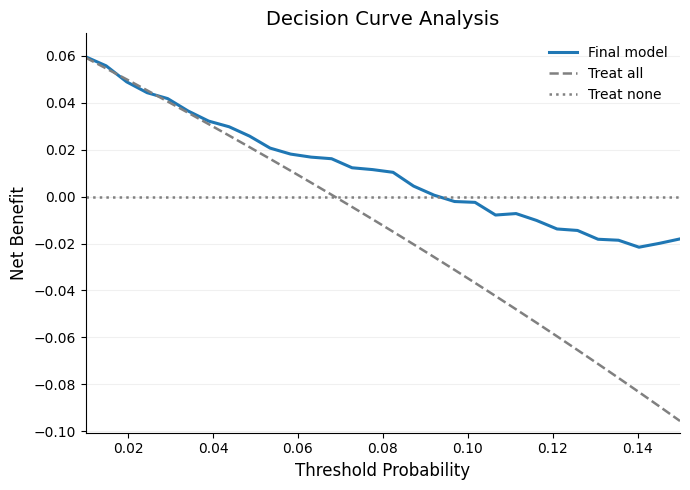


✅ DCA complete for final model
Saved:
- reports_ours/tables/DCA_Analysis_Final_Model.xlsx
- reports_ours/figures/dca/DCA_Final_Model.png


In [143]:
# =========================
# 10. Decision Curve Analysis
# Final model version
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs('reports_ours/tables', exist_ok=True)
os.makedirs('reports_ours/figures/dca', exist_ok=True)

# clinically relevant threshold range
thresholds = np.linspace(0.01, 0.15, 30)

# require final model outputs
required_objects = ['y_test', 'final_probs']
for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Run the final model block first.")

# -----------------------------
# Net benefit calculations
# -----------------------------
nb_model = [
    calculate_net_benefit(y_test, final_probs, t)
    for t in thresholds
]

nb_all = [
    calculate_net_benefit(y_test, np.ones(len(y_test)), t)
    for t in thresholds
]

nb_none = [0.0] * len(thresholds)

# save table
dca_df = pd.DataFrame({
    'Threshold': thresholds,
    'Net_Benefit_Final_Model': nb_model,
    'Treat_All': nb_all,
    'Treat_None': nb_none
})

dca_df.to_excel(
    'reports_ours/tables/DCA_Analysis_Final_Model.xlsx',
    index=False
)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7, 5), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

plt.plot(
    thresholds,
    nb_model,
    linewidth=2.2,
    label='Final model'
)

plt.plot(
    thresholds,
    nb_all,
    color='gray',
    linestyle='--',
    linewidth=1.8,
    label='Treat all'
)

plt.plot(
    thresholds,
    nb_none,
    color='gray',
    linestyle=':',
    linewidth=1.8,
    label='Treat none'
)

plt.xlabel('Threshold Probability', fontsize=12)
plt.ylabel('Net Benefit', fontsize=12)
plt.title('Decision Curve Analysis', fontsize=14)

plt.xlim(0.01, 0.15)

ymin = min(np.nanmin(nb_model), np.nanmin(nb_all), 0)
ymax = max(np.nanmax(nb_model), np.nanmax(nb_all), 0)
plt.ylim(ymin - 0.005, ymax + 0.01)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.grid(axis='y', alpha=0.18)
plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    'reports_ours/figures/dca/DCA_Final_Model.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("\n✅ DCA complete for final model")
print("Saved:")
print("- reports_ours/tables/DCA_Analysis_Final_Model.xlsx")
print("- reports_ours/figures/dca/DCA_Final_Model.png")

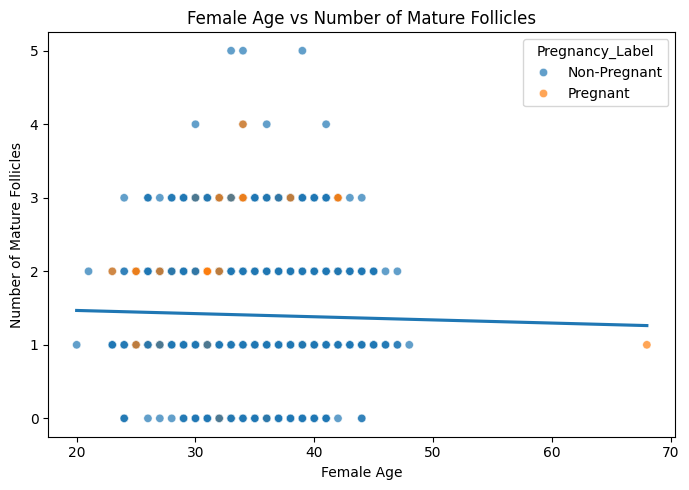

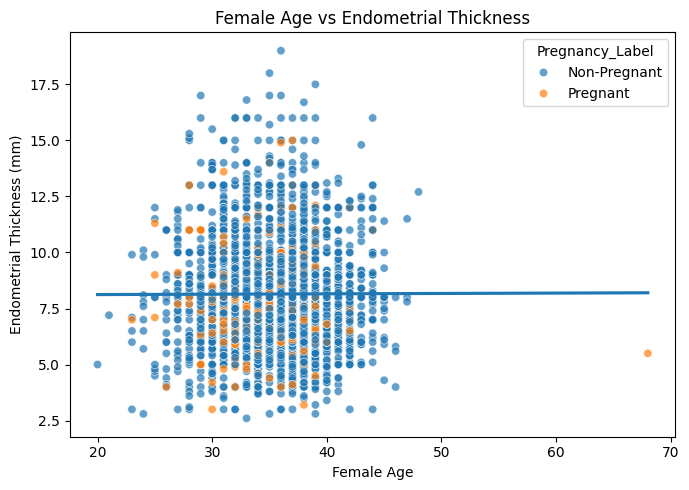

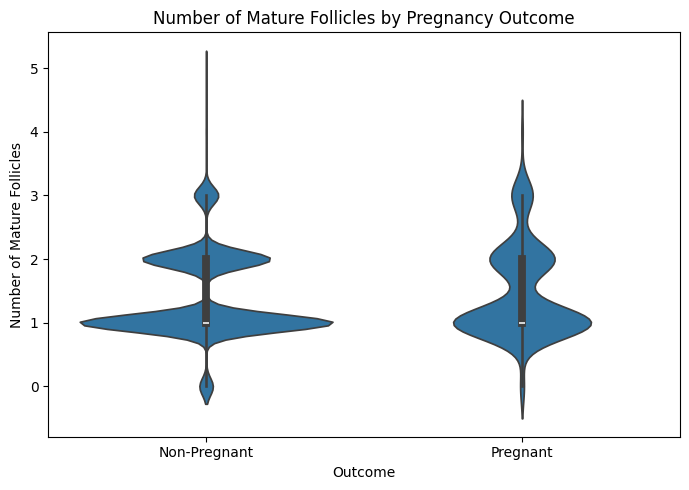

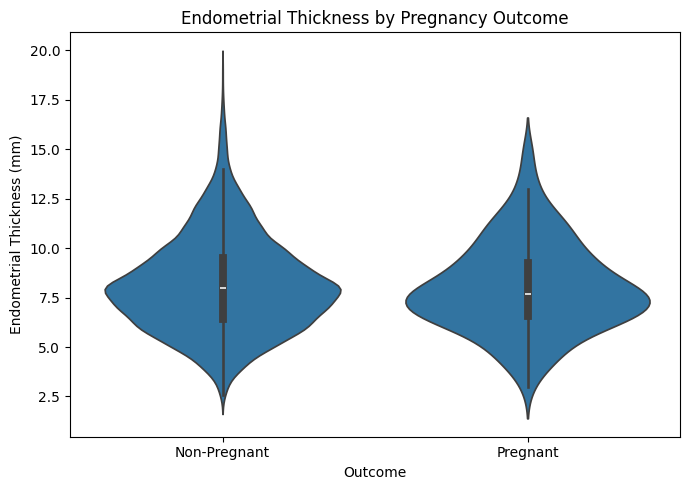

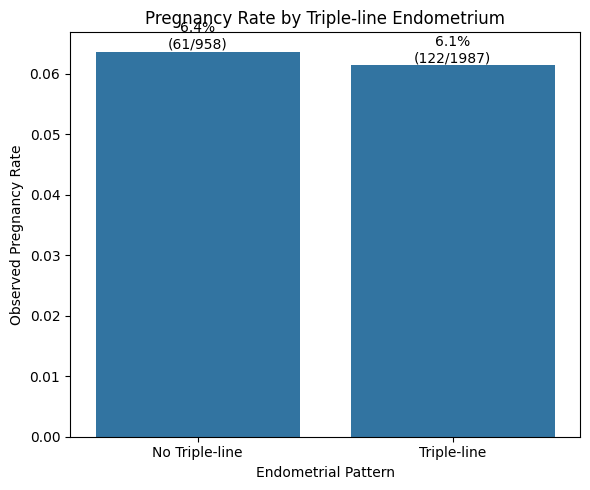

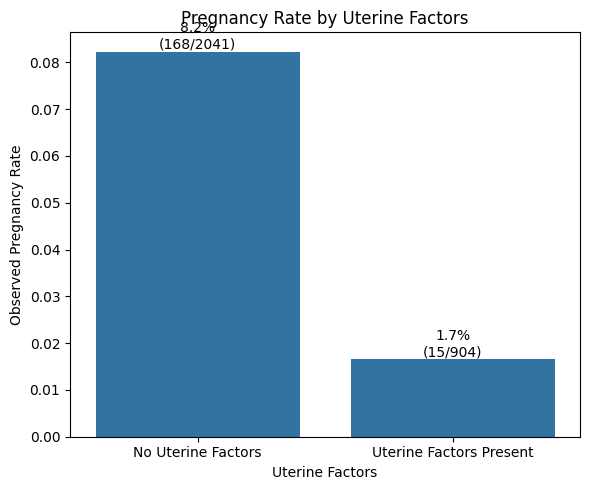

✅ Clinical relation plots saved to: reports_ours/figures/clinical_relations/


In [21]:
# ==========================================
# 11. Clinical Relation Plots for Bio Story
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('reports_ours/figures/clinical_relations', exist_ok=True)

plot_df = df.copy()

# กันคอลัมน์ขยะจาก Excel ถ้ายังมี
plot_df = plot_df.loc[:, ~plot_df.columns.str.startswith('Unnamed')]

# ทำ outcome label ให้อ่านง่าย
plot_df['Result'] = pd.to_numeric(plot_df['Result'], errors='coerce')
plot_df['Pregnancy_Label'] = plot_df['Result'].map({
    0: 'Non-Pregnant',
    1: 'Pregnant'
})

# -----------------------------
# 1) Female Age × Mature Follicles
# -----------------------------
if {'Age_Female', 'Mature_Follicle_Count', 'Result'}.issubset(plot_df.columns):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=plot_df,
        x='Age_Female',
        y='Mature_Follicle_Count',
        hue='Pregnancy_Label',
        alpha=0.7
    )
    sns.regplot(
        data=plot_df,
        x='Age_Female',
        y='Mature_Follicle_Count',
        scatter=False,
        ci=None
    )
    plt.title('Female Age vs Number of Mature Follicles')
    plt.xlabel('Female Age')
    plt.ylabel('Number of Mature Follicles')
    plt.tight_layout()
    plt.savefig(
        'reports_ours/figures/clinical_relations/Age_vs_MatureFollicles.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

# -----------------------------
# 2) Female Age × Endometrial Thickness
# -----------------------------
if {'Age_Female', 'Endometrium_Thickness', 'Result'}.issubset(plot_df.columns):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=plot_df,
        x='Age_Female',
        y='Endometrium_Thickness',
        hue='Pregnancy_Label',
        alpha=0.7
    )
    sns.regplot(
        data=plot_df,
        x='Age_Female',
        y='Endometrium_Thickness',
        scatter=False,
        ci=None
    )
    plt.title('Female Age vs Endometrial Thickness')
    plt.xlabel('Female Age')
    plt.ylabel('Endometrial Thickness (mm)')
    plt.tight_layout()
    plt.savefig(
        'reports_ours/figures/clinical_relations/Age_vs_EndometriumThickness.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

# -----------------------------
# 3) Mature Follicles × Pregnancy Outcome
# -----------------------------
if {'Mature_Follicle_Count', 'Pregnancy_Label'}.issubset(plot_df.columns):
    plt.figure(figsize=(7, 5))
    sns.violinplot(
        data=plot_df,
        x='Pregnancy_Label',
        y='Mature_Follicle_Count',
        inner='box'
    )
    plt.title('Number of Mature Follicles by Pregnancy Outcome')
    plt.xlabel('Outcome')
    plt.ylabel('Number of Mature Follicles')
    plt.tight_layout()
    plt.savefig(
        'reports_ours/figures/clinical_relations/MatureFollicles_by_PregnancyOutcome.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

# -----------------------------
# 4) Endometrial Thickness × Pregnancy Outcome
# -----------------------------
if {'Endometrium_Thickness', 'Pregnancy_Label'}.issubset(plot_df.columns):
    plt.figure(figsize=(7, 5))
    sns.violinplot(
        data=plot_df,
        x='Pregnancy_Label',
        y='Endometrium_Thickness',
        inner='box'
    )
    plt.title('Endometrial Thickness by Pregnancy Outcome')
    plt.xlabel('Outcome')
    plt.ylabel('Endometrial Thickness (mm)')
    plt.tight_layout()
    plt.savefig(
        'reports_ours/figures/clinical_relations/EndometriumThickness_by_PregnancyOutcome.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

# -----------------------------
# 5) Triple-line Endometrium × Pregnancy Outcome
# -----------------------------
if {'Endo_Type_Triple', 'Result'}.issubset(plot_df.columns):
    triple_summary = (
        plot_df
        .groupby('Endo_Type_Triple')
        .agg(
            Total_Cycles=('Result', 'count'),
            Pregnancies=('Result', 'sum')
        )
        .reset_index()
    )
    triple_summary['Observed_Pregnancy_Rate'] = (
        triple_summary['Pregnancies'] / triple_summary['Total_Cycles']
    )
    triple_summary['Triple_Label'] = triple_summary['Endo_Type_Triple'].map({
        0: 'No Triple-line',
        1: 'Triple-line'
    })

    plt.figure(figsize=(6, 5))
    sns.barplot(
        data=triple_summary,
        x='Triple_Label',
        y='Observed_Pregnancy_Rate'
    )
    plt.title('Pregnancy Rate by Triple-line Endometrium')
    plt.xlabel('Endometrial Pattern')
    plt.ylabel('Observed Pregnancy Rate')

    for i, row in triple_summary.iterrows():
        plt.text(
            i,
            row['Observed_Pregnancy_Rate'],
            f"{row['Observed_Pregnancy_Rate']:.1%}\n({int(row['Pregnancies'])}/{int(row['Total_Cycles'])})",
            ha='center',
            va='bottom'
        )

    plt.tight_layout()
    plt.savefig(
        'reports_ours/figures/clinical_relations/TripleLineEndometrium_by_PregnancyOutcome.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

# -----------------------------
# 6) Uterine Factors × Pregnancy Outcome
# -----------------------------
if {'Uterine_Factors', 'Result'}.issubset(plot_df.columns):
    uterine_summary = (
        plot_df
        .groupby('Uterine_Factors')
        .agg(
            Total_Cycles=('Result', 'count'),
            Pregnancies=('Result', 'sum')
        )
        .reset_index()
    )
    uterine_summary['Observed_Pregnancy_Rate'] = (
        uterine_summary['Pregnancies'] / uterine_summary['Total_Cycles']
    )
    uterine_summary['Uterine_Label'] = uterine_summary['Uterine_Factors'].map({
        0: 'No Uterine Factors',
        1: 'Uterine Factors Present'
    })

    plt.figure(figsize=(6, 5))
    sns.barplot(
        data=uterine_summary,
        x='Uterine_Label',
        y='Observed_Pregnancy_Rate'
    )
    plt.title('Pregnancy Rate by Uterine Factors')
    plt.xlabel('Uterine Factors')
    plt.ylabel('Observed Pregnancy Rate')

    for i, row in uterine_summary.iterrows():
        plt.text(
            i,
            row['Observed_Pregnancy_Rate'],
            f"{row['Observed_Pregnancy_Rate']:.1%}\n({int(row['Pregnancies'])}/{int(row['Total_Cycles'])})",
            ha='center',
            va='bottom'
        )

    plt.tight_layout()
    plt.savefig(
        'reports_ours/figures/clinical_relations/UterineFactors_by_PregnancyOutcome.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

print("✅ Clinical relation plots saved to: reports_ours/figures/clinical_relations/")